# C09 · Code walkthrough: vehicle weights (`vehicle/`, `weights/afdd.py`, the Halo aircraft build, XV-15 calibration)

**Track:** code walkthroughs. Every listing is printed from the repository with its real line numbers
(`show_source`). This notebook covers the mass side of the aircraft: the physical items, the empirical correlations
behind them (Raymer GA through AeroSandbox, AFDD/NDARC in `weights/afdd.py`), the assembly that sums them, the
function that builds the sized Halo from a `HaloDesign`, and the XV-15 calibration that sets every group factor.

| Module | Lines | What it holds |
|---|---|---|
| `weights/afdd.py` | 260 | AFDD82/83/00 rotor, drive and engine-section regressions; the NDARC tiltrotor wing (sec. 19-1.1) |
| `vehicle/condition.py` | 25 | `StructuralDesignCondition`: design mass, ultimate load factor, the q and L/D the correlations see |
| `vehicle/fuselage.py` | 56 | `Fuselage`: round or super-ellipse section, Raymer GA fuselage mass, CG at 45 % length |
| `vehicle/surfaces.py` | 244 | `Wing`, `HorizontalTail`, `VerticalTail` (Raymer GA), wing materials, `TiltrotorWingMassModel` |
| `vehicle/items.py` | 145 | `LandingGear`, `Systems`, `Payload`, `FuelLoad`, `Nacelles`, `InterconnectShaft`, `FixedEquipment` |
| `vehicle/aircraft.py` | 89 | `MassBreakdown`, `Aircraft`: sums `asb.MassProperties`, exports an `asb.Airplane` |
| `examples/halo_sizing.py` L624-898 | 275 | `ratio_reference_gear_stages`, `stage_mass_ratio`, `build_halo_aircraft` |
| `examples/xv15_reference.py` L150-298 | 149 | XV-15 aircraft, group mapping, `calibration_factors`, `solve_xv15_closure` |

**Who imports what.**
- `weights/afdd.py` imports only `aerosandbox.numpy` and units. It is imported by `vehicle/surfaces.py`,
  `vehicle/items.py`, `examples/halo_sizing.py`, `examples/xv15_reference.py`, `examples/tiltrotor_wing_calibration.py`
  and five test files.
- `vehicle/condition.py` (imports `asb` only) is imported by eleven examples and five tests; every mass call takes it.
- `vehicle/fuselage.py`, `surfaces.py`, `items.py` import AeroSandbox's `raymer_general_aviation_weights` (and `afdd`).
  They are used by `aircraft_mass_closure.py`, `coupled_sizing.py`, `halo_sizing.py`, `xv15_reference.py`
  (and `tiltrotor_wing_calibration.py` for surfaces).
- `vehicle/aircraft.py` imports `asb` only. It never imports the item classes: it duck-types anything with
  `get_mass_properties`. Used by seven examples (including `halo_sizing.py`, `xv15_reference.py`) and
  `tests/vehicle/test_aircraft.py`.
- `vehicle/powertrain_installation.py` is the powertrain item; it is covered with the topology (C07/C08), and used here
  only through `get_instance_mass_properties()`.

The order below is bottom-up: the equations first, then the items that call them, then the assembly, then the
Halo build and the calibration.

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

from dataclasses import fields, replace
from examples.halo_sizing import (HaloRequirements, build_halo_aircraft, calibration_factors, count_lanes_motor,
                                  ratio_reference_gear_stages, stage_mass_ratio)
from aircraft_closure.vehicle.condition import StructuralDesignCondition
from aircraft_closure.weights import afdd

ref, a, req = baseline(), baseline_assumptions(), HaloRequirements()
d = ref.design
aircraft = build_halo_aircraft(d, req, a)
factors = calibration_factors()
# The structural condition exactly as solve_halo_sizing_once builds it (halo_sizing.py L1252-1255), from the result.
cond = StructuralDesignCondition(mass_design_kg=ref.mass_takeoff_kg, load_factor_ultimate=a.load_factor_ultimate,
                                 velocity_cruise_m_s=ref.velocity_cruise_m_s, altitude_cruise_m=req.altitude_cruise_m,
                                 lift_to_drag_cruise=ref.lift_to_drag_cruise)
breakdown = aircraft.get_mass_breakdown(cond)
components = dict(ref.component_masses_kg)
print(f"MTOM {ref.mass_takeoff_kg:.2f} kg ({lb(ref.mass_takeoff_kg):,.0f} lb); cruise {ref.velocity_cruise_m_s / u.knot:.1f} kt "
      f"at {req.altitude_cruise_m:.0f} m; L/D {ref.lift_to_drag_cruise:.3f}")

MTOM 6885.06 kg (15,179 lb); cruise 165.5 kt at 3048 m; L/D 9.065


---
## 1. `weights/afdd.py`

### 1.1 Module docstring and the rotor group

In [2]:
show_source("src/aircraft_closure/weights/afdd.py", 1, 39)

# src/aircraft_closure/weights/afdd.py  lines 1-39
   1  """AFDD parametric rotorcraft weight equations, SI in and out.
   2  
   3  AeroSandbox's weight library covers fixed-wing groups (Raymer, Torenbeek) but
   4  no rotor, rotorcraft drive-system or tilting-nacelle groups; these fill that
   5  gap in the same functional style. Source: W. Johnson, NDARC Theory,
   6  NASA/TP-2009-215402, ch. 19 (AFDD weight models, regressions on turbine
   7  helicopters and tiltrotors). The published equations take lb, ft, ft/s, hp and
   8  rpm and return lb; each wrapper converts at its boundary and is otherwise the
   9  published equation with a unit technology factor. Powers are plain products,
  10  so every function accepts CasADi symbols. The tiltrotor wing (sec. 19-1.1) is a stiffness-based
  11  structural model in consistent SI rather than a regression.
  12  """
  13  from dataclasses import dataclass
  14  from typing import Any
  15  
  16  import aerosandbox.numpy as np
  17  impor

**L1-11 docstring.** AeroSandbox has Raymer and Torenbeek (fixed wing) but no rotor, drive or tilting-nacelle groups.
These are the AFDD regressions from Johnson's NDARC Theory (NASA/TP-2009-215402, ch. 19). Each wrapper takes SI,
converts to the published units (lb, ft, ft/s, hp, rpm) at the boundary, evaluates the published equation, and
converts the lb result back to kg. The technology factor is 1 inside: calibration lives in the caller
(`Xv15MassFactors`). "Powers are plain products" (L9-10): every term is `x**p`, which CasADi differentiates, so all
functions take symbols. The tiltrotor wing (L141 onward) is different: a stiffness model in consistent SI.

**L20-27 `mass_blades_afdd82_kg`** (NDARC eq. 19-2, 7.7 % mean error on 37 aircraft). All blades of all rotors:

$$W_{bl} = 0.02606\, N_{rotor}\, N_{bl}^{0.6592}\, R^{1.3371}\, c^{0.9959}\, V_{tip}^{0.6682}\, \nu_\beta^{2.5279}\quad[\mathrm{lb};\ R, c\ \mathrm{ft};\ V_{tip}\ \mathrm{ft/s}]$$

- `radius_m / u.foot` converts m to ft (`u.foot` = 0.3048 m); `* u.lbm` converts lb to kg at the end.
- `frequency_flap_per_rev` is the flap frequency in per rev. For a gimballed rotor (XV-15, Halo) NDARC uses the
  coning frequency (L24-25): 1.55 per rev in both (`Xv15Reference.frequency_coning_per_rev`, read off fig. 7.1.1).
  The 2.53 exponent makes this the most sensitive input: +10 % in ν gives +27 % blade mass.
- Linear in `count_rotors`: the regression is per rotor.

**L30-37 `mass_hub_afdd82_kg`** (10.2 % mean error on 35 aircraft):

$$W_{hub} = 0.003722\, N_{rotor}\, N_{bl}^{0.2807}\, R^{1.5377}\, V_{tip}^{0.4290}\, \nu_\beta^{2.1414}\, (W_{bl}/N_{rotor})^{0.5505}$$

The hub depends on the blade mass *per rotor* (L37 divides by `count_rotors`), so `mass_blades_kg` must be the
all-rotor value returned by the blade function (L33).

In [3]:
# XV-15 inputs (the same ones as tests/weights/test_afdd.py): two 25 ft, 3-blade rotors, 14 in chord, 740 ft/s, nu 1.55.
rotor = dict(count_rotors=2, count_blades=3, radius_m=12.5 * u.foot, chord_m=14 * u.inch, speed_tip_m_s=740 * u.foot,
             frequency_flap_per_rev=1.55)
blades_kg = afdd.mass_blades_afdd82_kg(**rotor)
hub_kg = afdd.mass_hub_afdd82_kg(2, 3, 12.5 * u.foot, 740 * u.foot, 1.55, blades_kg)
by_hand_blades_lb = 0.02606 * 2 * 3**0.6592 * 12.5**1.3371 * (14 / 12)**0.9959 * 740**0.6682 * 1.55**2.5279
by_hand_hub_lb = 0.003722 * 2 * 3**0.2807 * 12.5**1.5377 * 740**0.4290 * 1.55**2.1414 * (by_hand_blades_lb / 2)**0.5505
print(f"blades {lb(blades_kg):.3f} lb (by hand {by_hand_blades_lb:.3f}); hub {lb(hub_kg):.3f} lb (by hand {by_hand_hub_lb:.3f})")
check("AFDD82 blades = published equation in lb/ft (918.83 lb)", abs(lb(blades_kg) - by_hand_blades_lb) < 1e-9
      and abs(by_hand_blades_lb - 918.826599472869) < 1e-6)
check("AFDD82 hub = published equation (625.85 lb)", abs(lb(hub_kg) - 625.853370798386) < 1e-6)

def exponent(f, kwargs, name):
    # Local log-log slope by doubling one input: the exponent of a pure power law.
    return np.log(f(**{**kwargs, name: 2 * kwargs[name]}) / f(**kwargs)) / np.log(2)

blade_exp = {n: exponent(afdd.mass_blades_afdd82_kg, rotor, n) for n in
             ("count_rotors", "count_blades", "radius_m", "chord_m", "speed_tip_m_s", "frequency_flap_per_rev")}
print({k: round(v, 6) for k, v in blade_exp.items()})
check("blade exponents 1, 0.6592, 1.3371, 0.9959, 0.6682, 2.5279",
      np.allclose(list(blade_exp.values()), [1, 0.6592, 1.3371, 0.9959, 0.6682, 2.5279], atol=1e-12))
hub = dict(count_rotors=2, count_blades=3, radius_m=12.5 * u.foot, speed_tip_m_s=740 * u.foot,
           frequency_flap_per_rev=1.55, mass_blades_kg=blades_kg)
hub_exp = {n: exponent(afdd.mass_hub_afdd82_kg, hub, n) for n in
           ("count_blades", "radius_m", "speed_tip_m_s", "frequency_flap_per_rev", "mass_blades_kg")}
print({k: round(v, 6) for k, v in hub_exp.items()})
check("hub exponents 0.2807, 1.5377, 0.4290, 2.1414, 0.5505",
      np.allclose(list(hub_exp.values()), [0.2807, 1.5377, 0.4290, 2.1414, 0.5505], atol=1e-12))
check("hub: doubling rotors and blade mass together doubles the hub (per-rotor regression)",
      abs(afdd.mass_hub_afdd82_kg(**{**hub, "count_rotors": 4, "mass_blades_kg": 2 * blades_kg}) / hub_kg - 2) < 1e-12)

blades 918.827 lb (by hand 918.827); hub 625.853 lb (by hand 625.853)
PASS  AFDD82 blades = published equation in lb/ft (918.83 lb)
PASS  AFDD82 hub = published equation (625.85 lb)
{'count_rotors': np.float64(1.0), 'count_blades': np.float64(0.6592), 'radius_m': np.float64(1.3371), 'chord_m': np.float64(0.9959), 'speed_tip_m_s': np.float64(0.6682), 'frequency_flap_per_rev': np.float64(2.5279)}
PASS  blade exponents 1, 0.6592, 1.3371, 0.9959, 0.6682, 2.5279
{'count_blades': np.float64(0.2807), 'radius_m': np.float64(1.5377), 'speed_tip_m_s': np.float64(0.429), 'frequency_flap_per_rev': np.float64(2.1414), 'mass_blades_kg': np.float64(0.5505)}
PASS  hub exponents 0.2807, 1.5377, 0.4290, 2.1414, 0.5505
PASS  hub: doubling rotors and blade mass together doubles the hub (per-rotor regression)


### 1.2 Drive system and engine section

In [4]:
show_source("src/aircraft_closure/weights/afdd.py", 40, 90)

# src/aircraft_closure/weights/afdd.py  lines 40-90
  40  def mass_gearbox_rotor_shaft_afdd83_kg(power_drive_limit_W, speed_rotor_rad_s, speed_engine_rad_s, count_gearboxes,
  41                                         fraction_torque_second_rotor):
  42      """Gearboxes plus rotor shafts of the whole drive system (AFDD83; 7.7 % mean error on 30 aircraft).
  43  
  44      `fraction_torque_second_rotor` is the second main (or tail) rotor's share
  45      of rated torque; NDARC's typical value is 0.6 for twin main rotors.
  46      """
  47      return 57.72 * (power_drive_limit_W / u.hp)**0.8195 * (100 * fraction_torque_second_rotor)**0.0680 \
  48          * count_gearboxes**0.0663 * (speed_engine_rad_s / u.rpm / 1000)**0.0369 \
  49          / (speed_rotor_rad_s / u.rpm)**0.6379 * u.lbm
  50  
  51  
  52  def mass_gearbox_rotor_shaft_afdd00_kg(count_rotors, power_drive_limit_W, speed_engine_rad_s, speed_rotor_rad_s):
  53      """Gearboxes plus rotor shafts (AFDD00; 8.6 % mean err

**L40-49 `mass_gearbox_rotor_shaft_afdd83_kg`** (7.7 % on 30 aircraft). Gearboxes and rotor shafts of the whole
drive system:

$$W_{gb} = 57.72\, P^{0.8195}\, (100 f_Q)^{0.0680}\, N_{gb}^{0.0663}\, (\Omega_{eng}/1000)^{0.0369}\, /\, \Omega_{rotor}^{0.6379}\quad[P\ \mathrm{hp};\ \Omega\ \mathrm{rpm}]$$

- `power_drive_limit_W` is the *drive-system* limit (all rotors), so the caller passes `count × rating`.
- `fraction_torque_second_rotor` is the second rotor's share of rated torque (0.6 typical for twin main rotors,
  L44-45). Written as a percentage, as published.
- The engine-speed term is in thousands of rpm (L48). The rotor speed is in the denominator: torque is power over
  speed, and gearbox mass follows torque.

**L52-55 `mass_gearbox_rotor_shaft_afdd00_kg`** (8.6 % on 52 aircraft):

$$W_{gb} = 95.7634\, N_{rotor}^{0.38553}\, P^{0.78137}\, \Omega_{eng}^{0.09899}\, /\, \Omega_{rotor}^{0.80686}$$

The docstring (L53-54) says why Halo uses it when machines are sized by torque: the input-speed exponent 0.099 is a
ratio penalty (a faster motor needs a bigger reduction). L55 is one 177-character line with a run of spaces in the
middle: a joined continuation line (cosmetic only, see Findings).

**L58-63 `mass_drive_shaft_afdd82_kg`** (16 % on 28 aircraft). The interconnect. L61 forms the torque limit in hp/rpm;
the mass is `1.166 Q^0.3828 L^1.0455 N^0.3909 f_P^0.2693` with L in ft.

**L66-80 engine section** (AFDD82). Support and air induction are one regression,
`0.0412 (W_eng/N_eng)^1.1433 N_eng^1.3762`, split by `fraction_air_induction` (0.3 typical, range 0.1-0.6): support
takes `(1 - f)` (L68), air induction `f` (L74). Their sum does not depend on f. The cowling is
`0.2315 S_wet^1.3476` (ft², all nacelles less spinner).

**L83-88 `mass_rotor_group_afdd82_kg`**: blades, then the hub from those blades. This is the function the Halo build
calls; it never calls the blade and hub functions separately.

In [5]:
P_xv15, Om_xv15, Oe_xv15 = 3100 * u.hp, 565 * u.rpm, 20000 * u.rpm
gb83 = afdd.mass_gearbox_rotor_shaft_afdd83_kg(P_xv15, Om_xv15, Oe_xv15, 3, 0.6)
by_hand_83 = 57.72 * 3100**0.8195 * 60**0.0680 * 3**0.0663 * 20**0.0369 / 565**0.6379
gb00 = afdd.mass_gearbox_rotor_shaft_afdd00_kg(2, P_xv15, Oe_xv15, Om_xv15)
by_hand_00 = 95.7634 * 2**0.38553 * 3100**0.78137 * 20000**0.09899 / 565**0.80686
shaft = afdd.mass_drive_shaft_afdd82_kg(P_xv15, Om_xv15, 32.17 * u.foot, 2, 0.6)
by_hand_shaft = 1.166 * (3100 / 565)**0.3828 * 32.17**1.0455 * 2**0.3909 * 0.6**0.2693
print(f"AFDD83 {lb(gb83):.2f} lb (by hand {by_hand_83:.2f}); AFDD00 {lb(gb00):.2f} lb (by hand {by_hand_00:.2f}); "
      f"drive shaft {lb(shaft):.2f} lb (by hand {by_hand_shaft:.2f})")
check("AFDD83 = published equation (1168.21 lb at XV-15 inputs)", abs(lb(gb83) - by_hand_83) < 1e-6
      and abs(lb(gb83) - 1168.2101000180462) < 1e-6)
check("AFDD00 = published equation", abs(lb(gb00) - by_hand_00) < 1e-6)
check("AFDD82 drive shaft = published equation (96.31 lb)", abs(lb(shaft) - 96.31113528242616) < 1e-6
      and abs(lb(shaft) - by_hand_shaft) < 1e-6)

g83 = lambda **k: afdd.mass_gearbox_rotor_shaft_afdd83_kg(**k)
k83 = dict(power_drive_limit_W=P_xv15, speed_rotor_rad_s=Om_xv15, speed_engine_rad_s=Oe_xv15, count_gearboxes=3,
           fraction_torque_second_rotor=0.6)
e83 = [exponent(g83, k83, n) for n in k83]
k00 = dict(count_rotors=2, power_drive_limit_W=P_xv15, speed_engine_rad_s=Oe_xv15, speed_rotor_rad_s=Om_xv15)
e00 = [exponent(afdd.mass_gearbox_rotor_shaft_afdd00_kg, k00, n) for n in k00]
kds = dict(power_drive_limit_W=P_xv15, speed_rotor_rad_s=Om_xv15, length_drive_shaft_m=32.17 * u.foot,
           count_drive_shafts=2, fraction_power_second_rotor=0.6)
eds = [exponent(afdd.mass_drive_shaft_afdd82_kg, kds, n) for n in kds]
print("AFDD83", np.round(e83, 6), "\nAFDD00", np.round(e00, 6), "\nshaft ", np.round(eds, 6))
check("AFDD83 exponents (P, rotor, engine, N_gb, f_Q) = 0.8195, -0.6379, 0.0369, 0.0663, 0.0680",
      np.allclose(e83, [0.8195, -0.6379, 0.0369, 0.0663, 0.0680], atol=1e-12))
check("AFDD00 exponents (N_rotor, P, engine, rotor) = 0.38553, 0.78137, 0.09899, -0.80686",
      np.allclose(e00, [0.38553, 0.78137, 0.09899, -0.80686], atol=1e-12))
check("drive shaft exponents (P, rotor, L, N, f_P) = 0.3828, -0.3828, 1.0455, 0.3909, 0.2693",
      np.allclose(eds, [0.3828, -0.3828, 1.0455, 0.3909, 0.2693], atol=1e-12))

engines_kg = 2 * 600 * u.lbm
sup, air = afdd.mass_engine_support_afdd82_kg(engines_kg, 2), afdd.mass_air_induction_afdd82_kg(engines_kg, 2)
cowl = afdd.mass_engine_cowling_afdd82_kg(190 * u.foot**2)
print(f"support {lb(sup):.2f} lb, air induction {lb(air):.2f} lb, cowling {lb(cowl):.2f} lb")
check("engine support + air induction = one regression, independent of the split fraction",
      abs(afdd.mass_engine_support_afdd82_kg(engines_kg, 2, 0.1) + afdd.mass_air_induction_afdd82_kg(engines_kg, 2, 0.1)
          - (sup + air)) < 1e-9 and abs(lb(sup + air) - 0.0412 * 600**1.1433 * 2**1.3762) < 1e-9)
check("cowling = 0.2315 S^1.3476 (272.52 lb at 190 ft2)", abs(lb(cowl) - 0.2315 * 190**1.3476) < 1e-9
      and abs(lb(cowl) - 272.5206072521294) < 1e-6)
check("engine-section exponents: per-engine mass 1.1433, count 1.3762 - 1.1433, cowling area 1.3476",
      abs(exponent(lambda **k: afdd.mass_engine_support_afdd82_kg(**k), dict(mass_engines_kg=engines_kg, count_engines=2),
                   "mass_engines_kg") - 1.1433) < 1e-12
      and abs(exponent(lambda **k: afdd.mass_engine_support_afdd82_kg(**k), dict(mass_engines_kg=engines_kg, count_engines=2),
                       "count_engines") - (1.3762 - 1.1433)) < 1e-12
      and abs(exponent(lambda **k: afdd.mass_engine_cowling_afdd82_kg(**k), dict(area_wetted_nacelles_m2=17.65),
                       "area_wetted_nacelles_m2") - 1.3476) < 1e-12)
check("rotor group = blades + hub", abs(afdd.mass_rotor_group_afdd82_kg(**rotor) - blades_kg - hub_kg) < 1e-9)
print(f"At the XV-15 calibration point AFDD00 / AFDD83 = {gb00 / gb83:.3f} (AFDD83 with 3 gearboxes, AFDD00 with 2 rotors)")

AFDD83 1168.21 lb (by hand 1168.21); AFDD00 1072.86 lb (by hand 1072.86); drive shaft 96.31 lb (by hand 96.31)
PASS  AFDD83 = published equation (1168.21 lb at XV-15 inputs)
PASS  AFDD00 = published equation
PASS  AFDD82 drive shaft = published equation (96.31 lb)
AFDD83 [ 0.8195 -0.6379  0.0369  0.0663  0.068 ] 
AFDD00 [ 0.38553  0.78137  0.09899 -0.80686] 
shaft  [ 0.3828 -0.3828  1.0455  0.3909  0.2693]
PASS  AFDD83 exponents (P, rotor, engine, N_gb, f_Q) = 0.8195, -0.6379, 0.0369, 0.0663, 0.0680
PASS  AFDD00 exponents (N_rotor, P, engine, rotor) = 0.38553, 0.78137, 0.09899, -0.80686
PASS  drive shaft exponents (P, rotor, L, N, f_P) = 0.3828, -0.3828, 1.0455, 0.3909, 0.2693
support 112.34 lb, air induction 48.15 lb, cowling 272.52 lb
PASS  engine support + air induction = one regression, independent of the split fraction
PASS  cowling = 0.2315 S^1.3476 (272.52 lb at 190 ft2)
PASS  engine-section exponents: per-engine mass 1.1433, count 1.3762 - 1.1433, cowling area 1.3476
PASS  roto

The last line matters for Section 7: the transmission factor is calibrated with AFDD83, but the Halo build uses AFDD00
(see Findings).

### 1.3 Smoothing and the NDARC section form factors

In [6]:
show_source("src/aircraft_closure/weights/afdd.py", 91, 110)

# src/aircraft_closure/weights/afdd.py  lines 91-110
  91  def _positive_part(value, smoothing_scale=0.0):
  92      """max(0, value); a nonzero `smoothing_scale` (same units) gives a smooth hyperbola for gradient-based solves."""
  93      if isinstance(smoothing_scale, (int, float)) and smoothing_scale == 0:
  94          return np.fmax(value, 0)
  95      return 0.5 * (value + np.sqrt(value**2 + smoothing_scale**2))
  96  
  97  
  98  def section_form_factors_tiltrotor_wing(thickness_to_chord, fraction_chord_torque_box):
  99      """NDARC tiltrotor-wing section form factors (F_B, F_C, F_T, F_VH): beam bending, chord bending, torsion and
 100      spar-cap vertical/horizontal bending, relating airfoil and torque-box geometry to ideal shapes."""
 101      tau, w = thickness_to_chord, fraction_chord_torque_box
 102      factor_beam = (0.073 * np.sin(2 * np.pi * (tau - 0.151) / 0.1365) + 0.14598 * tau
 103                     + 0.610 * np.sin(2 * np.pi * (w + 0.080) / 2.1560) - (0.412

**L91-95 `_positive_part`**: NDARC's "replace by zero if negative". With a zero scale given as a Python number it
is `fmax(value, 0)` (L93-94), exact but with a kink. Otherwise it is the hyperbola

$$p(x) = \tfrac12\left(x + \sqrt{x^2 + s^2}\right)$$

which is smooth, always positive, tends to max(0, x) for |x| >> s, and equals s/2 at x = 0. The test on L93 is a
Python `isinstance` so a symbolic scale always takes the smooth branch. Halo sets `smoothing_wing_tiltrotor = 0.01`,
and the scale is 1 % of the required stiffness or moment (L199-200, L204-206, L231-232), so units always match.

**L98-108 `section_form_factors_tiltrotor_wing`**: NDARC's curve fits in thickness ratio τ and torque-box chord
fraction w. They relate the real section to the ideal shapes used below: `F_B` beam bending, `F_C` chord bending,
`F_T` torsion, `F_VH` spar-cap bending. They are dimensionless, published polynomials and sines; nothing here is
tuned in this repo.

In [7]:
FB, FC, FT, FVH = afdd.section_form_factors_tiltrotor_wing(0.23, 0.45)
print(f"tau 0.23, w 0.45: F_B {FB:.4f}, F_C {FC:.4f}, F_T {FT:.4f}, F_VH {FVH:.4f}")
x = np.linspace(-1, 1, 5)
print("hyperbola, s=0.1:", np.round(afdd._positive_part(x, 0.1), 4), " exact:", afdd._positive_part(x, 0))
check("smooth positive part >= max(0,x), equals s/2 at 0, error < s^2/(4|x|) away from 0",
      np.all(afdd._positive_part(x, 0.1) >= np.fmax(x, 0)) and abs(afdd._positive_part(0.0, 0.1) - 0.05) < 1e-15
      and abs(afdd._positive_part(1.0, 0.1) - 1.0) < 0.1**2 / 4)

tau 0.23, w 0.45: F_B 0.6048, F_C 0.4874, F_T 1.6384, F_VH 0.5018
hyperbola, s=0.1: [0.0025 0.005  0.05   0.505  1.0025]  exact: [0.  0.  0.  0.5 1. ]
PASS  smooth positive part >= max(0,x), equals s/2 at 0, error < s^2/(4|x|) away from 0


### 1.4 `TiltrotorWingMasses` and the tiltrotor wing signature

In [8]:
show_source("src/aircraft_closure/weights/afdd.py", 111, 171)

# src/aircraft_closure/weights/afdd.py  lines 111-171
 111  @dataclass(frozen=True)
 112  class TiltrotorWingMasses:
 113      """Result of `wing_tiltrotor_afdd_masses`. Masses in kg; stiffnesses in N m2 as realized (after the jump
 114      take-off increment); mode frequencies in rad/s from NDARC's single-mode relations. Fields may be symbolic."""
 115      mass_torque_box_kg: Any
 116      mass_spar_stiffness_kg: Any       # spar caps for the chord and beam bending-frequency requirements
 117      mass_spar_jump_kg: Any            # extra spar caps for the jump take-off bending moment
 118      mass_fairing_kg: Any
 119      mass_control_surfaces_kg: Any
 120      mass_fittings_kg: Any
 121      mass_fold_kg: Any
 122      stiffness_torsion_Nm2: Any
 123      stiffness_beam_Nm2: Any
 124      stiffness_chord_Nm2: Any
 125      frequency_torsion_rad_s: Any
 126      frequency_beam_rad_s: Any
 127      frequency_chord_rad_s: Any
 128      moment_jump_ultimate_Nm: Any
 129      area_to

**L111-138 `TiltrotorWingMasses`**: the result record. Seven masses (L115-121), the realized stiffnesses (after the
jump caps, L122-124), the single-mode frequencies they give (L125-127), the jump moment and two areas.
`mass_primary_kg` (L132-133) is box plus both spar-cap masses. `total` (L135-138) adds fairing, control surfaces,
fittings and fold. Only `total()` reaches the aircraft (through `TiltrotorWingMassModel.mass_kg`); the record is kept
for the whirl-flutter margins and the `wing_masses_kg` report.

**L141-152 signature.** About 40 inputs. Several have NDARC defaults that no caller changes: `count_tips=2`,
`thrust_max_rotor_N=None`, `efficiency_spar=1`, `correction_spar_strength=1`, `correction_moment_spar=1`. They are
NDARC's technology factors, kept so the function is the full published model.

**L153-171 docstring.** Three facts to defend in an interview:
- **One explicit pass, no iteration** (L157-158). NDARC computes the jump moment with the wing mass *before* the jump
  caps. Iterating would be a fixed-point loop; the framework forbids hidden loops (decision 004).
- The tip pitch inertia is `m_tip r_p²` (L159).
- **Plan 038 options** (L163-170): `ratio_depth_spar_cap` κ moves the caps from the full thickness to the airfoil
  depth at the spars (κ = 0.83 for a 23 % NACA section with spars at 0.15 and 0.60 chord). `thickness_min_torque_box_m`
  is a minimum wall gauge over the box perimeter. Both came from the plan 031 CalculiX check (caps 29 % over-strained,
  box walls 0.67 mm).

In [9]:
show_source("src/aircraft_closure/weights/afdd.py", 172, 221)

# src/aircraft_closure/weights/afdd.py  lines 172-221
 172      g_m_s2 = 9.80665
 173      thickness_m = thickness_to_chord * chord_m
 174      chord_torque_box_m = fraction_chord_torque_box * chord_m
 175      factor_beam, factor_chord, factor_torsion, factor_spar_cap = section_form_factors_tiltrotor_wing(
 176          thickness_to_chord, fraction_chord_torque_box)
 177      fraction_tip = count_tips * mass_tip_kg / mass_design_kg
 178      factor_mode = 1 - fraction_tip
 179      frequency_torsion_rad_s = frequency_torsion_per_rev * speed_rotor_design_rad_s
 180      frequency_beam_rad_s = frequency_beam_per_rev * speed_rotor_design_rad_s
 181      frequency_chord_rad_s = frequency_chord_per_rev * speed_rotor_design_rad_s
 182      bending_mass_kg_m3 = span_m**3 / 24 * 0.5 * mass_tip_kg * factor_mode
 183      torsion_inertia_kg_m3 = 0.5 * span_m * 0.5 * mass_tip_kg * radius_gyration_pylon_m**2
 184  
 185      # Torque box from the torsion frequency (ideal shape: a tube of radius t

**Geometry and mode masses (L172-183).**
- t = τc (L173), box chord = w c (L174), form factors (L175-176).
- `fraction_tip = 2 m_tip / W_D` (L177), `factor_mode = 1 - f_tip` (L178).
- Target frequencies ω = f × Ω (L179-181), with f in per rev and Ω = `speed_rotor_design_rad_s`.
- Equivalent masses of NDARC's single-mode relations (b = span, tip to tip):

$$M_b = \frac{b^3}{24}\cdot\frac{m_{tip}}{2}(1 - f_{tip}),\qquad I_t = \frac{b}{2}\cdot\frac{m_{tip}\, r_p^2}{2}$$

Units: M_b in kg m³ (so EI/M_b is s⁻²), I_t in kg m³ (GJ/I_t is s⁻²). The wing's own mass does not appear: the tip
masses dominate the modes. That is why the calibrated stiffness ends up below the published XV-15 stiffness and the
1.33 wing factor absorbs it (decision 024).

**Torque box from torsion (L185-193).**

$$GJ = \omega_T^2 I_t,\qquad A_{box} = \frac{4\, GJ}{G\, F_T\, t^2}$$

The ideal box is a tube with J = F_T A t²/4. If a minimum gauge is set (Halo: 1 mm), the floor area is
`t_min × 2(box chord + cap depth)` (L190), the box area becomes `A_min + p(A - A_min)` (L191, smooth max), and the
torsion stiffness is recomputed from the realized area (L193) so the whirl-flutter margin sees the thicker box.
The `if` on L189 is on a Python float: structure, not a symbolic switch.

**Spar caps for the bending frequencies (L195-209).**
- Required: `EI_C,req = ω_C² M_b` and `EI_B,req = ω_B² M_b` (L196-197).
- The box already provides `E F_C A_box (wc)²/4` in chord (L198) and `E F_B A_box t²/4` in beam (L202).
- Chord caps make up the deficit at a lever arm of the box chord (L199-201).
- Those chord caps also add beam stiffness at the cap depth κt, scaled by `F_VH` (L203).
- Beam caps make up what is left (L204-207). Total extra cap stiffness and area (L208-209).

**Masses (L211-220).** `m_box = A ρ b / η_box` (L211, η_box = 0.583 from the XV-15 calibration: less than 1 adds
non-ideal material). `m_spar = C_t A_spar ρ b / η_spar` (L212-213, C_t = 0.526). Fairing area is the wing outside
the attachment, aft of the box, less the control surfaces (L214-215). Fittings are a fraction of the *total*, so
`r = f/(1 - f)` of the rest (L218). L219-220 is the wing mass used by the jump moment: no jump caps yet.

In [10]:
show_source("src/aircraft_closure/weights/afdd.py", 222, 260)

# src/aircraft_closure/weights/afdd.py  lines 222-260
 222      # Jump take-off: ultimate root bending moment against the torque-box and spar-cap capacity.
 223      length_wing_m = span_m - width_fuselage_m
 224      thrust_capability_N = load_factor_jump * mass_design_kg * g_m_s2 / count_rotors
 225      if thrust_max_rotor_N is not None:
 226          thrust_capability_N = np.fmax(thrust_capability_N, thrust_max_rotor_N)
 227      moment_jump_ultimate_Nm = thrust_capability_N * length_wing_m * (
 228          0.75 * (1 - fraction_tip) - 0.375 * (length_wing_m / span_m) * (mass_wing_kg / mass_design_kg))
 229      moment_box_Nm = 2 * stiffness_beam_box_Nm2 * strain_ultimate / thickness_m
 230      moment_spar_Nm = 2 * correction_moment_spar * stiffness_spar_Nm2 * strain_ultimate / depth_cap_m
 231      moment_deficit_Nm = _positive_part(moment_jump_ultimate_Nm - moment_box_Nm - moment_spar_Nm,
 232                                         smoothing * moment_jump_ultimate_Nm)
 233     

**Jump take-off (L222-234).**
- Wing length outside the fuselage `L_w = b - w_fus` (L223). Thrust per rotor `T = n_jump W_D g / N_rotor` (L224),
  or a larger given maximum (L225-226, unused by callers).
- Ultimate root moment (L227-228):

$$M_{jump} = T\, L_w\left[0.75\,(1 - f_{tip}) - 0.375\,\frac{L_w}{b}\,\frac{m_{wing}}{W_D}\right]$$

  Tip and wing inertia relieve the moment: the rotor thrust accelerates the whole aircraft, so the tip masses and the
  wing push back. This is why moving the turbogenerators off the tips (plan 037) *raised* the jump caps (less inertia
  relief) while it lowered the torque box (less pitch inertia).
- Capacities at the ultimate strain ε (L229-230): the box at half-depth t/2 gives `2 EI_box ε / t`; the caps at κt
  give `2 EI_spar ε / (κt)`.
- Deficit (smooth max, L231-232) becomes extra caps `A = 2 ΔM / (ε E κt)` (L233) and their mass (L234).

**Fittings and fold (L236-239).** Fittings now include the jump caps. Fold mass is a fraction of everything including
both tip masses (Halo: 0).

**Realized stiffness and frequencies (L241-255).** The jump caps add beam stiffness (L243-244), so the realized beam
frequency is at least the target. The chord stiffness does not include the `F_VH` cross term the other way round.
Frequencies `ω = √(K/M)` (L251-253) are what the whirl-flutter margins use.

**L258-260 `__main__`**: prints the XV-15 rotor group for ν = 1.0 and 1.55 (a quick look at the coning sensitivity).

**Run it at the Halo inputs.** Recompute every step by hand from the model's own fields and compare with
`ref.wing_masses_kg` (the values the sizing reported).

In [11]:
mm = aircraft.wing.mass_model
w = mm.masses(aircraft.wing, cond)
mat, W_D = mm.material, cond.mass_design_kg
b, c = aircraft.wing.span_m(), aircraft.wing.chord_mean_m()
tau, wf, kappa, s = mm.thickness_to_chord, mm.fraction_chord_torque_box, mm.ratio_depth_spar_cap, mm.smoothing
t, cb = tau * c, wf * c
FB, FC, FT, FVH = afdd.section_form_factors_tiltrotor_wing(tau, wf)
f_tip = 2 * mm.mass_tip_kg / W_D
wT, wB, wC = (f * mm.speed_rotor_design_rad_s for f in
              (mm.frequency_torsion_per_rev, mm.frequency_beam_per_rev, mm.frequency_chord_per_rev))
Mb = b**3 / 24 * 0.5 * mm.mass_tip_kg * (1 - f_tip)
It = 0.5 * b * 0.5 * mm.mass_tip_kg * mm.radius_gyration_pylon_m**2
A_freq = 4 * wT**2 * It / (mat.modulus_shear_torque_box_Pa * FT * t**2)
A_min = mm.thickness_min_torque_box_m * 2 * (cb + kappa * t)
pp = lambda x, scale: 0.5 * (x + np.sqrt(x**2 + scale**2))
A_box = A_min + pp(A_freq - A_min, s * A_min)
EIC_box = mat.modulus_torque_box_Pa * FC * A_box * cb**2 / 4
EIB_box = mat.modulus_torque_box_Pa * FB * A_box * t**2 / 4
A_sc = pp(wC**2 * Mb - EIC_box, s * wC**2 * Mb) / (mat.modulus_spar_Pa * cb**2 / 4)
EI_capbeam = mat.modulus_spar_Pa * FVH * A_sc * (kappa * t)**2 / 4
EIB_sp = pp(wB**2 * Mb - EIB_box - EI_capbeam, s * wB**2 * Mb)
A_sb = EIB_sp / (mat.modulus_spar_Pa * (kappa * t)**2 / 4)
m_box = A_box * mat.density_torque_box_kg_m3 * b / mm.efficiency_torque_box
m_sp = mm.correction_spar_stiffness * (A_sc + A_sb) * mat.density_spar_kg_m3 * b
A_cs = mm.fraction_area_control_surfaces * aircraft.wing.area_m2
m_fair = ((b - mm.width_fuselage_m) * c * (1 - wf) - A_cs) * mm.unit_mass_fairing_kg_m2
m_cs = A_cs * mm.unit_mass_control_surfaces_kg_m2
r_fit = mm.fraction_fittings / (1 - mm.fraction_fittings)
m_wing_prejump = (1 + r_fit) * (m_box + m_sp + m_fair + m_cs)
L_w = b - mm.width_fuselage_m
M_jump = 2.0 * W_D * 9.80665 / 2 * L_w * (0.75 * (1 - f_tip) - 0.375 * L_w / b * m_wing_prejump / W_D)
cap = 2 * EIB_box * mat.strain_ultimate / t + 2 * (EI_capbeam + EIB_sp) * mat.strain_ultimate / (kappa * t)
A_jump = 2 * pp(M_jump - cap, s * M_jump) / (mat.strain_ultimate * mat.modulus_spar_Pa * kappa * t)
m_jump = A_jump * mat.density_spar_kg_m3 * b
m_fit = r_fit * (m_box + m_sp + m_jump + m_fair + m_cs)
hand = dict(mass_torque_box_kg=m_box, mass_spar_stiffness_kg=m_sp, mass_spar_jump_kg=m_jump, mass_fairing_kg=m_fair,
            mass_control_surfaces_kg=m_cs, mass_fittings_kg=m_fit, mass_fold_kg=0.0)
reported = dict(ref.wing_masses_kg)
print(f"span {b:.3f} m, mean chord {c:.4f} m, t {t:.4f} m, kappa {kappa:.4f}, m_tip {mm.mass_tip_kg:.2f} kg, "
      f"r_p {mm.radius_gyration_pylon_m:.4f} m, Omega {mm.speed_rotor_design_rad_s:.3f} rad/s")
print(f"box area: frequency {A_freq * 1e6:.1f} mm2, gauge floor {A_min * 1e6:.1f} mm2 -> {A_box * 1e6:.1f} mm2 "
      f"(wall {A_box / (2 * (cb + kappa * t)) * 1e3:.3f} mm)")
print(f"{'item':<26}{'by hand':>10}{'model':>10}{'sizing':>10}")
for k in hand:
    print(f"{k:<26}{hand[k]:10.3f}{getattr(w, k):10.3f}{reported[k]:10.3f}")
print(f"total {w.total():.3f} kg x factor {factors.wing_tiltrotor:.4f} = {factors.wing_tiltrotor * w.total():.3f} kg; "
      f"component 'wing' {components['wing']:.3f} kg")
check("hand recomputation of every wing line = afdd.wing_tiltrotor_afdd_masses",
      all(abs(hand[k] - getattr(w, k)) < 1e-9 for k in hand))
check("model reproduces baseline().wing_masses_kg", all(abs(reported[k] - getattr(w, k)) < 1e-6 for k in reported))
check("wing component = wing_tiltrotor factor x AFDD total", abs(factors.wing_tiltrotor * w.total() - components["wing"]) < 1e-6)
check("the 1 mm gauge floor is the active torque-box sizing (frequency area below it)", A_freq < A_min)
check("jump moment by hand", abs(M_jump - w.moment_jump_ultimate_Nm) < 1e-6 * M_jump)
check("realized frequencies >= targets (torsion, beam, chord)",
      w.frequency_torsion_rad_s >= wT and w.frequency_beam_rad_s >= wB * (1 - 1e-9) and w.frequency_chord_rad_s >= wC * (1 - 1e-9))
print(f"realized / target: torsion {w.frequency_torsion_rad_s / wT:.3f}, beam {w.frequency_beam_rad_s / wB:.3f}, "
      f"chord {w.frequency_chord_rad_s / wC:.3f}")

span 11.941 m, mean chord 1.9511 m, t 0.4488 m, kappa 0.8264, m_tip 767.18 kg, r_p 0.7857 m, Omega 56.281 rad/s
box area: frequency 2482.9 mm2, gauge floor 2497.7 mm2 -> 2504.8 mm2 (wall 1.003 mm)
item                         by hand     model    sizing
mass_torque_box_kg            85.206    85.206    85.206
mass_spar_stiffness_kg        25.781    25.781    25.781
mass_spar_jump_kg             17.998    17.998    17.998
mass_fairing_kg               73.219    73.219    73.219
mass_control_surfaces_kg      65.430    65.430    65.430
mass_fittings_kg              39.638    39.638    39.638
mass_fold_kg                   0.000     0.000     0.000
total 307.271 kg x factor 1.3274 = 407.870 kg; component 'wing' 407.870 kg
PASS  hand recomputation of every wing line = afdd.wing_tiltrotor_afdd_masses
PASS  model reproduces baseline().wing_masses_kg
PASS  wing component = wing_tiltrotor factor x AFDD total
PASS  the 1 mm gauge floor is the active torque-box sizing (frequency area below it)
PA

The torque box on the Halo is not sized by torsion at all: the frequency requirement asks for less wall than 1 mm,
so the gauge floor sets it (the smooth max puts A_box a hair above A_min). The two areas are within 1 %, so torsion
lands only 0.4 % above its target: the floor and the frequency requirement nearly coincide at this design. Chord sits
exactly on target (the chord caps are sized to it). Beam is 14 % above target because the jump caps add beam
stiffness after the frequency caps were sized.

**How the wing breakdown moves with the wing design rotor speed** (all else at the baseline). Torque box and the
frequency caps grow with Ω²; above the gauge floor the box takes over; the jump caps shrink as the stiffer box and
caps carry more of the jump moment.

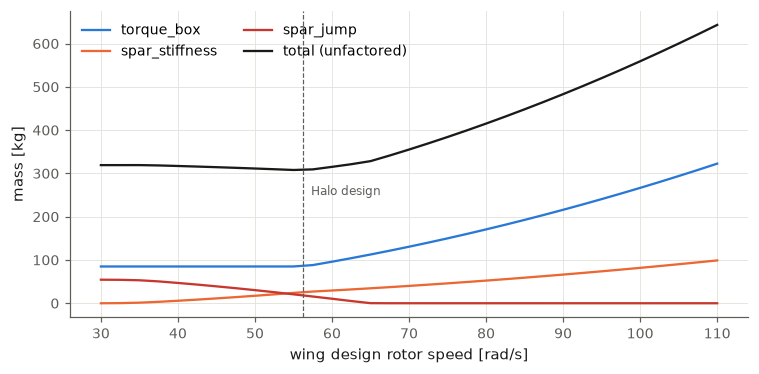

PASS  torque box grows ~ Omega^2 once torsion sizes it (above the gauge floor)
PASS  jump caps shrink as the frequency-sized structure grows


In [12]:
omegas = np.linspace(30, 110, 33)
rows = [replace(mm, speed_rotor_design_rad_s=o).masses(aircraft.wing, cond) for o in omegas]
fig, ax = plt.subplots(figsize=(7, 3.5))
for name, color in (("mass_torque_box_kg", blue), ("mass_spar_stiffness_kg", orange), ("mass_spar_jump_kg", red)):
    ax.plot(omegas, [getattr(r, name) for r in rows], color=color, label=name.replace("mass_", "").replace("_kg", ""))
ax.plot(omegas, [r.total() for r in rows], color=ink, label="total (unfactored)")
ax.axvline(mm.speed_rotor_design_rad_s, color=ink_muted, ls="--", lw=0.8)
ax.text(mm.speed_rotor_design_rad_s + 1, 250, "Halo design", color=ink_muted, fontsize=8)
ax.set_xlabel("wing design rotor speed [rad/s]"); ax.set_ylabel("mass [kg]"); ax.legend(ncol=2); plt.tight_layout(); plt.show()
hi = rows[-1]; lo = rows[0]
check("torque box grows ~ Omega^2 once torsion sizes it (above the gauge floor)",
      abs(rows[-1].mass_torque_box_kg / rows[-5].mass_torque_box_kg - (omegas[-1] / omegas[-5])**2) < 0.02)
check("jump caps shrink as the frequency-sized structure grows", hi.mass_spar_jump_kg < lo.mass_spar_jump_kg)

**Symbolic use.** Every line accepts CasADi expressions. A tiny `asb.Opti`: find the wing design rotor speed at which
the unfactored wing weighs 330 kg (one equation, one unknown).

In [13]:
opti = asb.Opti()
omega = opti.variable(init_guess=60.0, lower_bound=20.0)
total = replace(mm, speed_rotor_design_rad_s=omega).mass_kg(aircraft.wing, cond)
opti.subject_to(total == 330.0)
sol = opti.solve(verbose=False)
print(f"Omega for a 330 kg wing: {sol.value(omega):.3f} rad/s")
check("symbolic wing mass solves and matches a numeric re-evaluation",
      abs(replace(mm, speed_rotor_design_rad_s=sol.value(omega)).mass_kg(aircraft.wing, cond) - 330.0) < 1e-6)

Omega for a 330 kg wing: 65.322 rad/s
PASS  symbolic wing mass solves and matches a numeric re-evaluation


---
## 2. `vehicle/condition.py`

In [14]:
show_source("src/aircraft_closure/vehicle/condition.py")

# src/aircraft_closure/vehicle/condition.py  lines 1-25
   1  """Structural design condition shared by the empirical mass correlations."""
   2  from dataclasses import dataclass
   3  from typing import Any
   4  
   5  import aerosandbox as asb
   6  
   7  
   8  @dataclass(frozen=True)
   9  class StructuralDesignCondition:
  10      """Design gross mass and the flight condition the correlations are sized at.
  11  
  12      `mass_design_kg` is normally the caller's take-off mass variable, which is
  13      how the mass closure couples back into every correlation. Lift-to-drag is
  14      an assumption until aerodynamics exists (Tier 5); Raymer's fuselage
  15      correlation depends on it only weakly (exponent -0.072).
  16      """
  17      mass_design_kg: Any
  18      load_factor_ultimate: Any = 5.7
  19      velocity_cruise_m_s: Any = 60.0
  20      altitude_cruise_m: Any = 1000.0
  21      lift_to_drag_cruise: Any = 12.0
  22  
  23      def operating_point(self):
  24  

- **L8-21 `StructuralDesignCondition`**: the single object through which take-off mass reaches every correlation.
  `mass_design_kg` is normally the Opti take-off-mass variable (L12-13): that is how mass closure couples into
  every group, as one equality and no fixed-point loop (decision 004).
- **L18 `load_factor_ultimate`** default 5.7 (3.8 × 1.5, Raymer GA). Halo and the XV-15 pass 4.5 (3.0 × 1.5,
  TM X-62407 sec. 4.2).
- **L19-20** cruise speed and altitude. **L23-25 `operating_point`** turns them into an `asb.OperatingPoint`, whose
  `dynamic_pressure()` is the q of Raymer's correlations (wing q^0.006, horizontal tail q^0.168, vertical tail
  q^0.122, fuselage q^0.241).
- **L21** cruise L/D, used only by Raymer's fuselage (exponent -0.072).
- **The docstring is stale** at L13-15: "Lift-to-drag is an assumption until aerodynamics exists (Tier 5)". The Halo
  passes the *solved* cruise L/D and the *solved* cruise speed (`halo_sizing.py` L1252-1255). So the structural
  condition is itself coupled to the mission. See the cruise-q finding at the end.

In [15]:
op = cond.operating_point()
q_by_hand = 0.5 * asb.Atmosphere(altitude=req.altitude_cruise_m).density() * ref.velocity_cruise_m_s**2
print(f"Halo structural q = {op.dynamic_pressure():.1f} Pa ({op.dynamic_pressure() / u.psf:.2f} psf) at "
      f"{ref.velocity_cruise_m_s / u.knot:.1f} kt (the solved cruise speed), {req.altitude_cruise_m:.0f} m")
check("operating_point().dynamic_pressure() = 0.5 rho V^2 at the cruise altitude",
      abs(op.dynamic_pressure() - q_by_hand) < 1e-9 * q_by_hand)
opti = asb.Opti(); m = opti.variable(init_guess=6000.0)
print("symbolic design mass is carried as-is:", type(StructuralDesignCondition(m).mass_design_kg).__name__)

Halo structural q = 3271.6 Pa (68.33 psf) at 165.5 kt (the solved cruise speed), 3048 m
PASS  operating_point().dynamic_pressure() = 0.5 rho V^2 at the cruise altitude
symbolic design mass is carried as-is: MX


---
## 3. `vehicle/fuselage.py`

In [16]:
show_source("src/aircraft_closure/vehicle/fuselage.py")

# src/aircraft_closure/vehicle/fuselage.py  lines 1-56
   1  """Constant-section fuselage with conical nose and tail; Raymer GA mass (unpressurized).
   2  
   3  The section is round (`diameter_m`) unless `height_m` is given; then it is a
   4  super-ellipse `diameter_m` wide and `height_m` deep with exponent `shape`
   5  (2: ellipse; larger is boxier), as an unpressurized cargo fuselage. Models
   6  that need the width keep using `diameter_m`; fineness ratios use
   7  `diameter_equivalent_m()`.
   8  """
   9  from dataclasses import dataclass
  10  from typing import Any
  11  
  12  import aerosandbox as asb
  13  import aerosandbox.library.weights.raymer_general_aviation_weights as raymer
  14  import aerosandbox.numpy as np
  15  
  16  
  17  @dataclass(frozen=True)
  18  class Fuselage:
  19      length_m: Any = 7.0
  20      diameter_m: Any = 1.2
  21      nose_length_fraction: Any = 0.2
  22      tail_length_fraction: Any = 0.35
  23      x_nose_m: Any = 0.0
  24      z_m:

- **L1-7 docstring**: round section of `diameter_m` unless `height_m` is given; then a super-ellipse `diameter_m`
  wide and `height_m` deep with exponent `shape` (2 ellipse, larger boxier). Models that need the width keep using
  `diameter_m` (rotor clearance, AFDD wing attachment); fineness ratios use the geometric-mean diameter.
- **L17-27 fields.** Halo: 11.0 m long, 5.5 ft (1.676 m) wide, 2.0 m deep, shape 3.2 (plan 037: "archer halo is not
  pressurized. that's why it's so boxy"). `mass_factor` 1.70 is the layout-anchored factor of plan 037, not the
  XV-15 group factor (2.07, a crewed fuselage).
- **L29-34** section height and `√(w h)` equivalent diameter.
- **L36-48 `to_asb`**: four stations at fractions (0, nose, 1 - tail, 1) of the length with section scale
  (0.02, 1, 1, 0.1) (L38-39). The non-zero end sections keep AeroSandbox's wetted-area and volume formulas regular
  (L37). Round sections pass `radius` (L41); super-ellipse sections pass `width`, `height`, `shape` (L43-44).
- **L50-56 `get_mass_properties`**: Raymer GA fuselage on the `asb.Fuselage` (AeroSandbox
  `raymer_general_aviation_weights.mass_fuselage`):

$$W_{fus} = 0.052\, S_{wet}^{1.086}\, (N_z W_{dg})^{0.177}\, L_t^{-0.051}\, (L/D)^{-0.072}\, q^{0.241}\quad[\mathrm{lb, ft^2, ft, psf}]$$

  plus a pressurization term that is zero here (`pressure_differential` default 0). `L_t` is the wing-to-tail
  distance passed in by the aircraft (L51). CG at 45 % of the length (L56), z at the fuselage axis.

In [17]:
fus = aircraft.fuselage
af = fus.to_asb()
raw_lb = (0.052 * (af.area_wetted() / u.foot**2)**1.086 * (lb(cond.mass_design_kg) * cond.load_factor_ultimate)**0.177
          * (aircraft.distance_wing_to_tail_m() / u.foot)**-0.051 * cond.lift_to_drag_cruise**-0.072
          * (cond.operating_point().dynamic_pressure() / u.psf)**0.241)
print(f"wetted {af.area_wetted():.2f} m2, volume {af.volume():.2f} m3, d_eq {fus.diameter_equivalent_m():.4f} m, "
      f"wing-to-tail {aircraft.distance_wing_to_tail_m():.3f} m")
print(f"raw Raymer {raw_lb * u.lbm:.2f} kg x {fus.mass_factor} = {fus.mass_factor * raw_lb * u.lbm:.2f} kg; "
      f"sizing 'fuselage' {components['fuselage']:.2f} kg")
check("fuselage = 1.70 x Raymer GA by hand = baseline component", abs(fus.mass_factor * raw_lb * u.lbm - components["fuselage"]) < 1e-6)
check("fuselage CG at 45 % of its length", abs(breakdown.fuselage.x_cg - 0.45 * fus.length_m) < 1e-12)
round_tube = replace(fus, height_m=None, diameter_m=fus.diameter_equivalent_m())
print(f"round tube of the same equivalent diameter: wetted {round_tube.to_asb().area_wetted():.2f} m2 "
      f"(boxy {af.area_wetted():.2f} m2)")

wetted 51.34 m2, volume 21.45 m3, d_eq 1.8311 m, wing-to-tail 5.005 m
raw Raymer 329.52 kg x 1.7 = 560.19 kg; sizing 'fuselage' 560.19 kg
PASS  fuselage = 1.70 x Raymer GA by hand = baseline component
PASS  fuselage CG at 45 % of its length
round tube of the same equivalent diameter: wetted 47.10 m2 (boxy 51.34 m2)


---
## 4. `vehicle/surfaces.py`

### 4.1 Planform helpers, `Wing`, `HorizontalTail`

In [18]:
show_source("src/aircraft_closure/vehicle/surfaces.py", 1, 102)

# src/aircraft_closure/vehicle/surfaces.py  lines 1-102
   1  """Unswept trapezoidal lifting surfaces with Raymer general-aviation masses.
   2  
   3  Geometry is parameterized by planform area, aspect ratio and taper ratio and
   4  handed to `asb.Wing`, which owns span, MAC and area calculations. Masses call
   5  AeroSandbox's Raymer correlations (Aircraft Design: A Conceptual Approach,
   6  5th ed., sec. 15.3.3; general aviation scope) on that geometry; `mass_factor`
   7  is a dimensionless calibration multiplier. CG sits at 40 % of the MAC.
   8  
   9  Tier 20: `Wing.mass_model` selects an interchangeable wing mass submodel.
  10  None keeps Raymer (the simplest model); `TiltrotorWingMassModel` is the AFDD
  11  tiltrotor wing (NDARC sec. 19-1.1), sized by torsion and bending frequencies
  12  in per rev and by a jump take-off.
  13  """
  14  from dataclasses import dataclass, field
  15  from typing import Any
  16  
  17  import aerosandbox as asb
  18  import aerosandbox.l

- **L1-13 docstring**: unswept trapezoids parameterized by (S, AR, λ), handed to `asb.Wing`, which owns span, MAC and
  area. Raymer GA (5th ed. sec. 15.3.3) masses with a dimensionless `mass_factor`; CG at 40 % MAC. **L9-12**: Tier 20
  `Wing.mass_model` swaps the wing mass model (None = Raymer, the simplest model kept).
- **L25-29 `_trapezoid_chords_m`**:

$$b = \sqrt{S\,AR},\qquad c_r = \frac{2S}{b\,(1+\lambda)},\qquad c_t = \lambda c_r$$

  For the symmetric surfaces b is the full span; for the fin it is the height (one panel).
- **L32-34 `_cg_x_m`**: unswept, so the MAC leading edge is at the root leading edge; CG = x_LE + 0.4 MAC.
- **L37-52 `_SymmetricSurface`**: a mixin, not a dataclass. `span_m` and `chord_root_m` recompute the trapezoid each
  call (cheap; keeps the dataclass frozen and symbolic). `to_asb` (L47-52) builds a root section at y = 0 and a tip
  at y = b/2 with `symmetric=True`.
- **L55-65 `Wing` fields.** `asb_name` is a class attribute (no annotation), so it is not a dataclass field.
  `mass_model` (L65): None or any object with `mass_kg(wing, condition)`.
- **L67-68 `chord_mean_m` = S/b**: the AFDD model's chord (equal to the root chord at λ = 1, the Halo).
- **L70-80 `get_mass_properties`**: Raymer GA wing with `mass_fuel_in_wing=0` (L76: no fuel in the wing), or the
  submodel (L78). The `mass_factor` multiplies either (L79). Halo: `factors.wing_tiltrotor` = 1.327 on the AFDD wing.
- **L83-100 `HorizontalTail`**: `elevator_chord_fraction` (L93) is not used by the mass; `controls/stability.py`
  and `trajectory/corridor.py` read it for elevator effectiveness. Raymer GA horizontal tail (L97-99):
  `0.016 (N_z W)^0.414 q^0.168 S^0.896 (100 t/c)^-0.12 AR^0.043 λ^-0.02`.

In [19]:
wing, ht = aircraft.wing, aircraft.horizontal_tail
bw, cr = wing.span_m(), wing.chord_root_m()
ct = cr * wing.taper_ratio
aw = wing.to_asb()
print(f"wing: S {wing.area_m2:.3f} m2, AR {wing.aspect_ratio}, b {bw:.3f} m, c_r {cr:.4f} m, MAC {aw.mean_aerodynamic_chord():.4f} m")
check("trapezoid: b = sqrt(S AR), S = b (c_r + c_t)/2, asb area agrees",
      abs(bw - np.sqrt(wing.area_m2 * wing.aspect_ratio)) < 1e-12 and abs(bw * (cr + ct) / 2 - wing.area_m2) < 1e-9
      and abs(aw.area() - wing.area_m2) < 1e-9)
check("wing CG = x_LE + 0.4 MAC", abs(breakdown.wing.x_cg - (wing.x_le_root_m + 0.4 * aw.mean_aerodynamic_chord())) < 1e-12)
hta = ht.to_asb()
ht_lb = (0.016 * (lb(cond.mass_design_kg) * cond.load_factor_ultimate)**0.414 * (op.dynamic_pressure() / u.psf)**0.168
         * (hta.area() / u.foot**2)**0.896 * (100 * ht.airfoil.max_thickness())**-0.12 * hta.aspect_ratio()**0.043
         * ht.taper_ratio**-0.02)
print(f"horizontal tail: Raymer by hand {ht_lb * u.lbm:.3f} kg x {ht.mass_factor:.4f} = {ht.mass_factor * ht_lb * u.lbm:.3f} kg; "
      f"sizing {components['horizontal_tail']:.3f} kg")
check("horizontal tail = tail factor x Raymer GA by hand", abs(ht.mass_factor * ht_lb * u.lbm - components["horizontal_tail"]) < 1e-6)
raymer_wing = replace(wing, mass_model=None, mass_factor=factors.wing).get_mass_properties(cond).mass
print(f"for comparison, Raymer GA wing x XV-15 Raymer factor {factors.wing:.3f}: {raymer_wing:.1f} kg "
      f"(AFDD wing {components['wing']:.1f} kg)")

wing: S 23.299 m2, AR 6.12, b 11.941 m, c_r 1.9511 m, MAC 1.9511 m
PASS  trapezoid: b = sqrt(S AR), S = b (c_r + c_t)/2, asb area agrees
PASS  wing CG = x_LE + 0.4 MAC
horizontal tail: Raymer by hand 41.791 kg x 1.1256 = 47.039 kg; sizing 47.039 kg
PASS  horizontal tail = tail factor x Raymer GA by hand
for comparison, Raymer GA wing x XV-15 Raymer factor 1.930: 576.0 kg (AFDD wing 407.9 kg)


### 4.2 `VerticalTail` and wing materials

In [20]:
show_source("src/aircraft_closure/vehicle/surfaces.py", 103, 173)

# src/aircraft_closure/vehicle/surfaces.py  lines 103-173
 103  @dataclass(frozen=True)
 104  class VerticalTail:
 105      """Single fin; aspect ratio is height^2 / area."""
 106      area_m2: Any = 1.6
 107      aspect_ratio: Any = 1.6
 108      taper_ratio: Any = 0.6
 109      x_le_root_m: Any = 6.0
 110      z_root_m: Any = 0.5
 111      airfoil: Any = field(default_factory=lambda: asb.Airfoil("naca0012"))
 112      mass_factor: Any = 1.0
 113      rudder_chord_fraction: Any = 0.3
 114  
 115      def height_m(self):
 116          return _trapezoid_chords_m(self.area_m2, self.aspect_ratio, self.taper_ratio)[0]
 117  
 118      def chord_root_m(self):
 119          return _trapezoid_chords_m(self.area_m2, self.aspect_ratio, self.taper_ratio)[1]
 120  
 121      def to_asb(self):
 122          height_m, chord_root_m, chord_tip_m = _trapezoid_chords_m(self.area_m2, self.aspect_ratio, self.taper_ratio)
 123          return asb.Wing(name="vertical_tail", symmetric=False, xsecs=[
 124   

- **L103-113 `VerticalTail`**: a single fin; AR = h²/S (L105). The XV-15's two fins are modelled as one of equal
  area. `rudder_chord_fraction` (L113) is read by `controls/stability.py`, not by the mass.
- **L115-119** height (the trapezoid "span") and root chord. **L121-127 `to_asb`**: root at `z_root_m`, tip at
  `z_root_m + h`, `symmetric=False`.
- **L129-135** Raymer GA fin, `0.073 (N_z W)^0.376 q^0.122 S^0.876 (100 t/c / cos Λ)^-0.49 (AR / cos²Λ)^0.357 λ^0.039`;
  CG at 40 % MAC in x and 40 % of the height in z (L135). Λ is AeroSandbox's quarter-chord sweep. The fin's leading
  edge is vertical (both sections at `x_le_root_m`, L124-125), so with λ = 0.6 its quarter chord leans forward and
  cos Λ is not 1: "unswept" in the module docstring means an unswept leading edge. The wing and horizontal tail have
  λ = 1 on the Halo, so for them Λ = 0.
- **L138-147 `WingMaterial`**: densities, moduli, and `strain_ultimate`, the allowable used against the jump moment
  (the minimum of spar and torque box, L140-141).
- **L150-161 `aluminium_wing_material`** (the XV-15's): E = 10e6 psi, G = 3.8e6 psi, ρ = 0.1 lb/in³, ε = 0.0068
  (the table's limit strain used as the NDARC allowable, L154-155). `psi = u.lbf / u.inch**2` (L157), density
  `0.1 u.lbm / u.inch**3` (L158).
- **L164-171 `graphite_epoxy_wing_material`** (the Halo's, `a.wing_material = "graphite_epoxy"`): box E 9e6 psi,
  spar E 18e6 psi, G 3.75e6 psi, ρ 0.06 lb/in³, ε 0.0047. Source for both: Acree, Peyran and Johnson (AHS 1999,
  table 5; NASA/TP-2004-212262).

In [21]:
vt = aircraft.vertical_tail
vta = vt.to_asb()
# The leading edge is unswept, so with taper 0.6 the quarter chord is swept forward; Raymer uses that sweep.
cos_L = np.cosd(vta.mean_sweep_angle())
vt_lb = (0.073 * (lb(cond.mass_design_kg) * cond.load_factor_ultimate)**0.376 * (op.dynamic_pressure() / u.psf)**0.122
         * (vta.area() / u.foot**2)**0.876 * (100 * vt.airfoil.max_thickness() / cos_L)**-0.49
         * (vta.aspect_ratio() / cos_L**2)**0.357 * vt.taper_ratio**0.039)
print(f"fin quarter-chord sweep {vta.mean_sweep_angle():.3f} deg (leading edge unswept)")
print(f"fin: h {vt.height_m():.3f} m, AR from asb {vta.aspect_ratio():.4f} (input {vt.aspect_ratio}); "
      f"Raymer {vt.mass_factor * vt_lb * u.lbm:.3f} kg, sizing {components['vertical_tail']:.3f} kg")
check("fin AR = h^2 / S", abs(vt.height_m()**2 / vt.area_m2 - vt.aspect_ratio) < 1e-12)
check("vertical tail = tail factor x Raymer GA by hand", abs(vt.mass_factor * vt_lb * u.lbm - components["vertical_tail"]) < 1e-6)
check("fin CG z = root + 0.4 h", abs(breakdown.vertical_tail.z_cg - (vt.z_root_m + 0.4 * vt.height_m())) < 1e-12)
from aircraft_closure.vehicle.surfaces import aluminium_wing_material, graphite_epoxy_wing_material
al, gr = aluminium_wing_material(), graphite_epoxy_wing_material()
print(f"aluminium: rho {al.density_torque_box_kg_m3:.0f} kg/m3, E {al.modulus_torque_box_Pa / 1e9:.1f} GPa, "
      f"G {al.modulus_shear_torque_box_Pa / 1e9:.1f} GPa; graphite-epoxy: rho {gr.density_spar_kg_m3:.0f} kg/m3, "
      f"E spar {gr.modulus_spar_Pa / 1e9:.1f} GPa")
check("10e6 psi = 68.95 GPa; 0.1 lb/in3 = 2768 kg/m3",
      abs(al.modulus_spar_Pa - 68.9476e9) < 1e6 and abs(al.density_spar_kg_m3 - 2767.99) < 0.1)
check("Halo wing material is graphite-epoxy", aircraft.wing.mass_model.material == gr)

fin quarter-chord sweep -3.071 deg (leading edge unswept)
fin: h 2.523 m, AR from asb 2.3300 (input 2.33); Raymer 35.835 kg, sizing 35.835 kg
PASS  fin AR = h^2 / S
PASS  vertical tail = tail factor x Raymer GA by hand
PASS  fin CG z = root + 0.4 h
aluminium: rho 2768 kg/m3, E 68.9 GPa, G 26.2 GPa; graphite-epoxy: rho 1661 kg/m3, E spar 124.1 GPa
PASS  10e6 psi = 68.95 GPa; 0.1 lb/in3 = 2768 kg/m3
PASS  Halo wing material is graphite-epoxy


### 4.3 `TiltrotorWingMassModel`

In [22]:
show_source("src/aircraft_closure/vehicle/surfaces.py", 174, 244)

# src/aircraft_closure/vehicle/surfaces.py  lines 174-244
 174  @dataclass(frozen=True)
 175  class TiltrotorWingMassModel:
 176      """AFDD tiltrotor wing mass submodel for `Wing.mass_model` (NDARC sec. 19-1.1; equations in `weights.afdd`).
 177  
 178      Span is the torque-box length (rotor centreline to centreline); chord is the mean chord. Frequencies are in
 179      per rev of `speed_rotor_design_rad_s`: the wing is built so that its torsion, beam and chord modes sit at those
 180      fractions of that rotor speed. Whirl-flutter placement at other rotor speeds is checked by the caller with
 181      `frequency_per_rev` (a margin, not a hidden loop). `mass_tip_kg` is the mass on one tip.
 182  
 183      Defaults are the XV-15 (plan 024): published modes at the 458 rpm airplane-mode rotor speed (Acree et al.
 184      stick model: symmetric torsion 8.3 Hz, beam 3.3 Hz, chord 6.3 Hz); torque-box chord ratio 0.45 (assumed); the
 185      torque-box efficiency, spar taper correct

- **L176-188 docstring.** Span is the torque-box length, rotor centreline to centreline: on the Halo the nacelles sit
  at y = ±b/2 (`build_halo_aircraft` L896), so the wing span is that length. Frequencies are in per rev of
  `speed_rotor_design_rad_s`; whirl-flutter placement at the other rotor speeds is a margin in the caller (L180-181).
- **L189-193** the inputs the Halo build computes: tip mass, pylon radius of gyration, design rotor speed, fuselage
  width; attachment width defaults to the fuselage width (L229).
- **L194-196** XV-15 symmetric modes in per rev of 458 rpm: 8.3, 3.3, 6.3 Hz → 1.087, 0.432, 0.825.
- **L197-200** section: τ 0.23, box chord fraction 0.45 (assumed), κ and minimum gauge (plan 038; defaults NDARC).
- **L202-208** calibrated constants. Control-surface fraction 0.185 = (11.0 + 20.2) / 169 ft²; fairing 10.92 kg/m²
  (108 lb on 48.3 ft²); control surfaces 15.18 kg/m² (97 lb on 31.2 ft²); fittings 0.129; η_box 0.583 and C_t 0.526
  back-solved in `examples/tiltrotor_wing_calibration.py` so the model reproduces the XV-15 breakdown from its
  *published stiffness*.
- **L209-211** rotors, 2 g jump, smoothing.
- **L213-235 `masses`**: a pure keyword pass-through to `afdd.wing_tiltrotor_afdd_masses` with span and mean chord
  from the `Wing`, design mass from the condition, control-surface area = fraction × wing area (L225). Not passed:
  `count_tips` (stays 2), `thrust_max_rotor_N`, `efficiency_spar`, `correction_spar_strength`,
  `correction_moment_spar` (all NDARC defaults). With `count_rotors = 4` the tip count would still be 2.
- **L237-238 `mass_kg`** is the interface `Wing.get_mass_properties` calls (unfactored total).
- **L240-244 `frequency_per_rev`** (static): realized frequencies divided by any rotor speed. The sizing calls it at
  every airplane-mode point (`halo_sizing.py` L1286-1293) and constrains torsion and beam per rev ≥ the design values.
  Chord is returned but not constrained.

In [23]:
wf_rec = ref.whirl_flutter[0]
tor, beam, chord = mm.frequency_per_rev(w, wf_rec["speed_rotor_rad_s"])
print(f"{wf_rec['label']}: rotor {wf_rec['speed_rotor_rad_s']:.3f} rad/s -> torsion {tor:.4f}, beam {beam:.4f} per rev "
      f"(reported {wf_rec['torsion_per_rev']:.4f}, {wf_rec['beam_per_rev']:.4f}); required {mm.frequency_torsion_per_rev:.3f}, "
      f"{mm.frequency_beam_per_rev:.3f}")
check("frequency_per_rev reproduces the sizing's whirl-flutter record",
      abs(tor - wf_rec["torsion_per_rev"]) < 1e-9 and abs(beam - wf_rec["beam_per_rev"]) < 1e-9)
worst = min(ref.whirl_flutter, key=lambda r: r["beam_per_rev"])
print(f"lowest beam margin: {worst['label']} at {worst['beam_per_rev']:.4f} per rev (limit {mm.frequency_beam_per_rev:.4f})")
check("XV-15 per-rev defaults = 8.3 / 3.3 / 6.3 Hz at 458 rpm",
      np.allclose([mm.frequency_torsion_per_rev, mm.frequency_beam_per_rev, mm.frequency_chord_per_rev],
                  [8.3 * 60 / 458, 3.3 * 60 / 458, 6.3 * 60 / 458]))

climb: rotor 27.592 rad/s -> torsion 2.2277, beam 1.0090 per rev (reported 2.2277, 1.0090); required 1.087, 0.432
PASS  frequency_per_rev reproduces the sizing's whirl-flutter record
lowest beam margin: max_speed at 0.7133 per rev (limit 0.4323)
PASS  XV-15 per-rev defaults = 8.3 / 3.3 / 6.3 Hz at 458 rpm


---
## 5. `vehicle/items.py`

### 5.1 Landing gear, systems, payload, fuel

In [24]:
show_source("src/aircraft_closure/vehicle/items.py", 1, 75)

# src/aircraft_closure/vehicle/items.py  lines 1-75
   1  """Landing gear, systems, payload, nacelle, drive-shaft and fixed-equipment mass items."""
   2  from dataclasses import dataclass
   3  from typing import Any
   4  
   5  import aerosandbox as asb
   6  import aerosandbox.library.weights.raymer_general_aviation_weights as raymer
   7  
   8  from aircraft_closure.weights import afdd
   9  
  10  
  11  @dataclass(frozen=True)
  12  class LandingGear:
  13      """Tricycle gear; Raymer GA main and nose correlations (fixed unless `is_retractable`)."""
  14      length_main_m: Any = 0.6
  15      length_nose_m: Any = 0.5
  16      x_main_m: Any = 3.6
  17      x_nose_m: Any = 1.0
  18      z_m: Any = -0.6
  19      mass_factor: Any = 1.0
  20      is_retractable: bool = False
  21  
  22      def get_mass_properties(self, condition):
  23          mass_main_kg = raymer.mass_main_landing_gear(self.length_main_m, condition.mass_design_kg,
  24                                       

- **L11-28 `LandingGear`**: Raymer GA main and nose gear. AeroSandbox's main gear is
  `0.095 (n_l W)^0.768 L^0.409` with n_l = 1.5 × 2 = 3 (its `n_gear=2` default), and nose
  `0.125 (n_l W)^0.566 L^0.845` with n_l = 1.5 × 1 (`n_gear=1`); L in ft. AeroSandbox's "ultimate landing load
  factor" is just 1.5 × the gear count. A fixed main gear gets × (5.7 - 0.7)/5.7 inside AeroSandbox; `is_retractable` (L20) selects
  it. The two items are summed as two `MassProperties` (L27-28), so the gear CG is mass-weighted between the main
  and nose stations. Halo: 3 ft struts, retractable, factor `alighting_gear` = 0.869.
- **L31-52 `Systems`**: Raymer GA flight controls `0.053 L_fus^1.536 b^0.371 (N_z W 1e-4)^0.80` built on a
  one-wing, one-fuselage `asb.Airplane` (L46-49), plus installed avionics `2.117 W_uninst^0.933` (L50). The Halo
  passes 0 kg of avionics (they are in the itemised fixed equipment), so this item is flight controls only, × 3.786
  (the XV-15 hydraulics and flight controls group over Raymer, L35-36 explains why the factor lives here).
- **L55-73 `Payload`, `FuelLoad`**: point masses. Fuel is the usable fuel at take-off (L67).

In [25]:
import aerosandbox.library.weights.raymer_general_aviation_weights as raymer
lg = aircraft.landing_gear
W_lb = lb(cond.mass_design_kg)
main_lb = 0.095 * (3.0 * W_lb)**0.768 * (lg.length_main_m / u.foot)**0.409
nose_lb = 0.125 * (1.5 * W_lb)**0.566 * (lg.length_nose_m / u.foot)**0.845
print(f"gear: main {main_lb * u.lbm:.2f} + nose {nose_lb * u.lbm:.2f} kg, x {lg.mass_factor:.4f} = "
      f"{lg.mass_factor * (main_lb + nose_lb) * u.lbm:.2f} kg; sizing {components['landing_gear']:.2f} kg")
check("landing gear = factor x (Raymer main + nose) by hand", abs(lg.mass_factor * (main_lb + nose_lb) * u.lbm - components["landing_gear"]) < 1e-6)
x_gear = (main_lb * lg.x_main_m + nose_lb * lg.x_nose_m) / (main_lb + nose_lb)
check("gear CG is the mass-weighted main/nose station", abs(breakdown.landing_gear.x_cg - x_gear) < 1e-9)
sysm = aircraft.systems
fc_lb = 0.053 * (fus.length_m / u.foot)**1.536 * (wing.span_m() / u.foot)**0.371 * (W_lb * cond.load_factor_ultimate * 1e-4)**0.80
print(f"flight controls: Raymer {fc_lb * u.lbm:.2f} kg x {sysm.mass_factor:.4f} = {sysm.mass_factor * fc_lb * u.lbm:.2f} kg; "
      f"avionics {raymer.mass_avionics(sysm.mass_avionics_uninstalled_kg):.1f} kg; sizing 'systems' {components['systems']:.2f} kg")
check("systems = factor x Raymer flight controls (avionics 0)", abs(sysm.mass_factor * fc_lb * u.lbm - components["systems"]) < 1e-6)
check("payload and fuel are point masses at their stations",
      breakdown.payload.mass == req.mass_payload_kg and abs(breakdown.fuel.mass - d.mass_fuel_kg) < 1e-12)

gear: main 255.36 + nose 41.98 kg, x 0.8690 = 258.39 kg; sizing 258.39 kg
PASS  landing gear = factor x (Raymer main + nose) by hand
PASS  gear CG is the mass-weighted main/nose station
flight controls: Raymer 107.56 kg x 3.7865 = 407.27 kg; avionics 0.0 kg; sizing 'systems' 407.27 kg
PASS  systems = factor x Raymer flight controls (avionics 0)
PASS  payload and fuel are point masses at their stations


### 5.2 Nacelles, interconnect shaft, fixed equipment

In [26]:
show_source("src/aircraft_closure/vehicle/items.py", 76, 145)

# src/aircraft_closure/vehicle/items.py  lines 76-145
  76  @dataclass(frozen=True)
  77  class Nacelles:
  78      """Engine section of all nacelles: support, cowling and air induction (AFDD82).
  79  
  80      `mass_engines_kg` is the dry mass of all engines the nacelles carry, usually
  81      the installed turboshaft mass expression. Pylon structure is not included.
  82  
  83      Optional geometry (Tier 21): a symmetric pair of bodies of revolution of
  84      `length_m` x `diameter_m` centred at (`x_m`, +/-`y_m`, `z_m`); the spinner is
  85      the body's nose. Without it the nacelles have no aerodynamic shape.
  86      """
  87      mass_engines_kg: Any
  88      count_engines: Any = 2
  89      area_wetted_m2: Any = 17.7
  90      fraction_air_induction: Any = 0.3
  91      x_m: Any = 3.0
  92      z_m: Any = 0.6
  93      mass_factor: Any = 1.0
  94      length_m: Any = None
  95      diameter_m: Any = None
  96      y_m: Any = 0.0
  97  
  98      def to_asb(self):
  9

- **L76-96 `Nacelles`**: the AFDD82 *engine section*: support, cowling and air induction (L78). `mass_engines_kg` is
  all engines (L80-81). Pylon structure is not included (L81). Optional geometry (L83-85): two bodies of revolution at
  ±y.
- **L98-108 `to_asb`**: empty list without geometry (L100-101). Otherwise stations at 0, 25, 70, 100 % of the length
  with radius fractions 0.05, 1, 1, 0.3 (L104), centred on `x_m` (L106: `x + (fraction - 0.5) L`), one per side.
- **L110-116 mass**: support + air induction + cowling (L111-115), × `mass_factor` (Halo: the powerplant factor
  1.145). CG at one point (x_m, z_m).
- **L119-134 `InterconnectShaft`**: AFDD82 drive shaft (L132-133). The XV-15 has one; the series-hybrid Halo has
  none (its rotors are linked electrically), so `drive_shaft` is None and weighs 0.
- **L137-145 `FixedEquipment`**: a given mass. Halo: the itemised uncrewed equipment (587 lb,
  `mass_equipment_from_items_kg(halo_equipment_items)`).

In [27]:
nac = aircraft.nacelles
nac_kg = factors.powerplant * (afdd.mass_engine_support_afdd82_kg(nac.mass_engines_kg, nac.count_engines)
                               + afdd.mass_air_induction_afdd82_kg(nac.mass_engines_kg, nac.count_engines)
                               + afdd.mass_engine_cowling_afdd82_kg(nac.area_wetted_m2))
print(f"nacelles: engines {nac.mass_engines_kg:.2f} kg, wetted {nac.area_wetted_m2:.2f} m2 -> {nac_kg:.3f} kg; "
      f"sizing {components['nacelles']:.3f} kg; bodies {[f.name for f in nac.to_asb()]} at y = +/-{nac.y_m:.3f} m")
check("nacelles = powerplant factor x AFDD82 engine section", abs(nac_kg - components["nacelles"]) < 1e-6)
check("Halo has no interconnect shaft (drive_shaft None -> 0 kg)", aircraft.drive_shaft is None and components["drive_shaft"] == 0.0)
check("fixed equipment = itemised 587 lb", abs(components["equipment"] - a.mass_equipment_kg) < 1e-9
      and abs(lb(a.mass_equipment_kg) - 587) < 0.5)

nacelles: engines 368.41 kg, wetted 17.65 m2 -> 194.831 kg; sizing 194.831 kg; bodies ['nacelle_right', 'nacelle_left'] at y = +/-5.971 m
PASS  nacelles = powerplant factor x AFDD82 engine section
PASS  Halo has no interconnect shaft (drive_shaft None -> 0 kg)
PASS  fixed equipment = itemised 587 lb


---
## 6. `vehicle/aircraft.py`

In [28]:
show_source("src/aircraft_closure/vehicle/aircraft.py")

# src/aircraft_closure/vehicle/aircraft.py  lines 1-89
   1  """Aircraft assembly: composes physical components and aggregates mass and CG.
   2  
   3  The assembly never solves. Mass closure is the caller's explicit equality
   4  `mass_takeoff_kg == aircraft.get_mass(StructuralDesignCondition(mass_takeoff_kg))`.
   5  CG aggregation is AeroSandbox's `MassProperties` addition.
   6  """
   7  from dataclasses import dataclass
   8  from typing import Any
   9  
  10  import aerosandbox as asb
  11  
  12  
  13  def _optional_mass_properties(item):
  14      """Items without a design condition; an absent item weighs nothing."""
  15      return item.get_mass_properties() if item is not None else asb.MassProperties(mass=0)
  16  
  17  
  18  @dataclass(frozen=True)
  19  class MassBreakdown:
  20      wing: Any
  21      horizontal_tail: Any
  22      vertical_tail: Any
  23      fuselage: Any
  24      landing_gear: Any
  25      systems: Any
  26      powertrain: Any
  27      payl

- **L1-6 docstring**: the assembly never solves. Mass closure is the *caller's* equality
  `mass_takeoff_kg == aircraft.get_mass(StructuralDesignCondition(mass_takeoff_kg))`; the Halo writes it as the ratio
  `mass_takeoff_kg / total.mass == 1` (`halo_sizing.py` L1300, scaled to order one). CG aggregation is
  `asb.MassProperties.__add__` (mass-weighted).
- **L13-15 `_optional_mass_properties`**: optional items (fuel, nacelles, drive shaft, equipment) weigh 0 when None.
  Their `get_mass_properties()` takes no condition: they are not correlations in design mass.
- **L18-40 `MassBreakdown`**: one `MassProperties` per item. `total` (L33-36) is the sum; `mass_empty_kg` (L38-40)
  removes payload and fuel. Empty mass therefore *includes* fixed equipment and the battery.
- **L43-56 `Aircraft`**: twelve items. Types are `Any`: the assembly duck-types.
- **L58-61 `distance_wing_to_tail_m`**: wing root quarter chord to tail root quarter chord (Raymer's tail arm), passed
  to the fuselage (L68).
- **L63-77 `get_mass_breakdown`**: each item gets what its correlation needs: surfaces, gear and systems take the
  condition; the fuselage also the tail arm; systems also the wing and fuselage (L70); powertrain and payload nothing.
- **L79-83** mass and CG x as one-liners over the breakdown (each call rebuilds it; cheap, no state).
- **L85-89 `to_asb`**: wings, tails, fuselage and nacelle bodies as an `asb.Airplane` for the aerodynamics.

**Run it: reproduce `baseline().component_masses_kg` from the rebuilt aircraft.**

In [29]:
from aircraft_closure.vehicle.aircraft import MassBreakdown
print(f"{'item':<16}{'rebuilt kg':>12}{'sizing kg':>12}")
for f in fields(MassBreakdown):
    print(f"{f.name:<16}{getattr(breakdown, f.name).mass:12.3f}{components[f.name]:12.3f}")
total = breakdown.total()
print(f"{'total':<16}{total.mass:12.3f}{ref.mass_takeoff_kg:12.3f}")
check("every component mass reproduces baseline().component_masses_kg",
      all(abs(getattr(breakdown, k).mass - v) < 1e-6 for k, v in components.items()))
check("closure: total = MTOM", abs(total.mass - ref.mass_takeoff_kg) < 1e-6)
check("mass_empty_kg = total - payload - fuel = baseline().mass_empty_kg", abs(breakdown.mass_empty_kg() - ref.mass_empty_kg) < 1e-6)
x_rotor = d.x_le_wing_m + 0.25 * aircraft.wing.chord_root_m()
print(f"CG x {total.x_cg:.4f} m; rotor (wing quarter chord) {x_rotor:.4f} m")
check("CG on the rotor axis (the hover pitch-trim equality, halo_sizing.py L1301)", abs(total.x_cg - x_rotor) < 1e-6)
installed = dict((n, m) for n, m in ref.powertrain_masses_kg)
check("powertrain item = sum of installed instances = baseline().powertrain_masses_kg",
      all(abs(it.mass_properties.mass - installed[it.instance_name]) < 1e-6
          for it in aircraft.powertrain.get_instance_mass_properties())
      and abs(sum(installed.values()) - components["powertrain"]) < 1e-6)
airplane = aircraft.to_asb()
print("asb.Airplane:", [w_.name for w_ in airplane.wings], [f_.name for f_ in airplane.fuselages])

item              rebuilt kg   sizing kg
wing                 407.870     407.870
horizontal_tail       47.039      47.039
vertical_tail         35.835      35.835
fuselage             560.186     560.186
landing_gear         258.387     258.387
systems              407.272     407.272
powertrain          2870.943    2870.943
payload              900.000     900.000
fuel                 936.443     936.443
nacelles             194.831     194.831
drive_shaft            0.000       0.000
equipment            266.259     266.259
total               6885.064    6885.064
PASS  every component mass reproduces baseline().component_masses_kg
PASS  closure: total = MTOM
PASS  mass_empty_kg = total - payload - fuel = baseline().mass_empty_kg
CG x 5.1113 m; rotor (wing quarter chord) 5.1113 m
PASS  CG on the rotor axis (the hover pitch-trim equality, halo_sizing.py L1301)
PASS  powertrain item = sum of installed instances = baseline().powertrain_masses_kg
asb.Airplane: ['wing', 'horizontal_tail'

**Mass closure on the rebuilt aircraft.** With the design fixed, only the take-off mass feeding the correlations is
unknown. One equation, one unknown, no iteration: the solve must return the baseline MTOM.

In [30]:
opti = asb.Opti()
m_to = opti.variable(init_guess=5000.0, scale=1000.0, lower_bound=1000.0)
condition_sym = replace(cond, mass_design_kg=m_to)
opti.subject_to(m_to / aircraft.get_mass(condition_sym) == 1)
sol = opti.solve(verbose=False)
print(f"closed MTOM {sol.value(m_to):.4f} kg from a 5,000 kg guess (baseline {ref.mass_takeoff_kg:.4f} kg)")
check("fixed-design closure returns the baseline MTOM", abs(sol.value(m_to) - ref.mass_takeoff_kg) < 1e-4)
dm = 1.0
growth = (aircraft.get_mass(replace(cond, mass_design_kg=ref.mass_takeoff_kg + dm)) - total.mass) / dm
print(f"d(structure)/d(MTOM) at fixed design: {growth:.4f} kg/kg -> growth factor 1/(1 - {growth:.3f}) = {1 / (1 - growth):.3f}")

closed MTOM 6885.0642 kg from a 5,000 kg guess (baseline 6885.0642 kg)
PASS  fixed-design closure returns the baseline MTOM


d(structure)/d(MTOM) at fixed design: 0.1142 kg/kg -> growth factor 1/(1 - 0.114) = 1.129


The last line is the weight-growth sensitivity at fixed geometry: each kilogram of design mass adds structure (about 0.11 kg/kg: wing, tails, fuselage,
gear, controls). The full sizing has a larger growth factor because the powertrain,
rotor and fuel also scale with mass through the design variables.

---
## 7. `examples/halo_sizing.py`: `build_halo_aircraft`

### 7.1 Gear-stage helpers, factors, machine mass models

In [31]:
show_source("examples/halo_sizing.py", 624, 662)

# examples/halo_sizing.py  lines 624-662
 624  def ratio_reference_gear_stages():
 625      """The XV-15 engine-to-rotor ratio (20,000 / 565 rpm, 35.4:1), where the AFDD transmission factor is calibrated."""
 626      reference = Xv15Reference()
 627      return reference.speed_engine_rad_s / reference.speed_rotor_hover_rad_s
 628  
 629  
 630  def stage_mass_ratio(stage_model, ratio):
 631      """Plan 033: drive mass relative to the AFDD drive at the XV-15 calibration ratio; `ratio` is fast/slow (>= 1)."""
 632      return stage_model.mass_factor(ratio) / stage_model.mass_factor(ratio_reference_gear_stages())
 633  
 634  
 635  def build_halo_aircraft(design, requirements=HaloRequirements(), assumptions=HaloAssumptions(), factors=None,
 636                          lapse_exponent=None):
 637      a, d = assumptions, design
 638      factors = factors if factors is not None else calibration_factors()
 639      lapse_exponent = lapse_exponent if lapse_exponent is not None else fit_la

- **L624-627 `ratio_reference_gear_stages`**: 20,000 / 565 rpm = 35.4:1, the XV-15 engine-to-rotor ratio where the
  transmission factor was calibrated.
- **L630-632 `stage_mass_ratio`** (plan 033): drive mass relative to the drive at 35.4:1, as the ratio of
  `GearStageModel.mass_factor` = 1 + 0.3 (n_stages - 1). Used so AFDD's own ratio exponent is not counted twice.
- **L637-639**: XV-15 factors and the lapse exponent are computed on each call unless passed in (both cheap:
  explicit equation solves).
- **L640** rubber-machine ratios (peak torque 2.5 Q̂, rated power 1.25 ω̂Q̂, max speed 2.5 ω̂) for the McDonald map.
- **L641-646** validation of the machine-mass switch (fail fast on a typo).
- **L647-655** with the Tier 15 electrical layer the machines are bare (inverters are components) and get bus-voltage
  limits; otherwise a torque-density model (inverters included) or the specific-power model.
- **L656-662** the plan 033 database model; the generator uses the same model. Halo baseline: `"units"`, so these
  rubber models are replaced below.

In [32]:
show_source("examples/halo_sizing.py", 663, 701)

# examples/halo_sizing.py  lines 663-701
 663      speed_peak_motor_rad_s = d.speed_peak_motor_rad_s if d.speed_peak_motor_rad_s is not None else a.speed_peak_motor_rad_s
 664      if d.speed_peak_generator_rad_s is not None:
 665          speed_peak_generator_rad_s = d.speed_peak_generator_rad_s
 666      elif by_torque and not a.generator_step_up:
 667          speed_peak_generator_rad_s = a.speed_output_turboshaft_rad_s    # generator on the engine output shaft
 668      else:
 669          speed_peak_generator_rad_s = a.speed_peak_generator_rad_s
 670      reduction_ratio = 1.0 if a.direct_drive_rotor else (d.reduction_ratio if d.reduction_ratio is not None
 671                                                          else a.reduction_ratio)
 672      thermal = dict(thermal_model=LumpedThermalModel(a.specific_heat_machine_J_kg_K, a.temperature_max_machine_C,
 673                                                      a.temperature_coolant_C)) if a.thermal_model else {}
 674      moto

- **L663-669** machine speeds: design variables when present, otherwise assumptions; a generator on the engine output
  shaft runs at 1,210 rpm (L667) when there is no step-up.
- **L670-671** reduction ratio: 1 for direct drive, else the design variable.
- **L672-673** Tier 19: a lumped thermal model per machine (the motor rating becomes continuous).
- **L674-677** rubber McDonald machines at (ω̂, Q̂).
- **L678-689** plan 035 `"units"`: `unit_machine` replaces limits and mass with n whole units (Evolito D1500 motor
  units, 40 kg; Helix SPX242 generator units, 31.2 kg). `baseline_assumptions()` fixes n = 2 motor units and 3 generator
  units (the integer re-solve).
- **L692-694** lanes (2, Tier 18 redundancy). The rotor gearbox rating is a design variable with the thermal model
  (L693), else lanes × motor rating.
- **L695-699** rotor geometry: R = √(A/π); chord from solidity σ = N c / (π R); design rotor speed Ω = V_tip / R.
- **L700-701** rotor group mass = rotor factor (0.693) × AFDD82 blades + hub with ν = 1.55.

In [33]:
inst = aircraft.powertrain.topology.instances
motor, gearbox, rotor_c = inst["motor"].component, inst["gearbox"].component, inst["propulsor"].component
R = np.sqrt(d.area_disk_m2 / np.pi)
chord = d.solidity * np.pi * R / a.count_blades
Omega = d.speed_tip_m_s / R
rotors_kg = factors.rotor * afdd.mass_rotor_group_afdd82_kg(a.count_rotors, a.count_blades, R, chord, d.speed_tip_m_s,
                                                           a.frequency_coning_per_rev)
print(f"R {R:.4f} m, chord {chord:.4f} m, Omega {Omega:.3f} rad/s ({Omega / u.rpm:.1f} rpm); "
      f"rotors {rotors_kg:.3f} kg = 2 x {rotor_c.mass_kg:.3f}")
check("rotor mass = rotor factor x AFDD82 group / 2 per rotor", abs(rotors_kg / 2 - rotor_c.mass_kg) < 1e-9)
print(f"motor: {a.count_units_motor} units x {a.mass_unit_motor_kg} kg = {motor.get_mass():.1f} kg per lane, "
      f"{inst['motor'].count} lane motors; generator {inst['generator'].component.get_mass():.1f} kg x {inst['generator'].count}")
check("unit machines: lane motor = 2 x 40 kg (+ integrated inverter), generator = 3 x 31.2 kg (+ inverter)",
      abs(motor.get_mass() - (2 * 40 + motor.power_rated_W / a.specific_power_inverter_W_kg)) < 1e-9
      and abs(inst["generator"].component.get_mass() - (3 * 31.2 + inst["generator"].component.power_rated_W
                                                         / a.specific_power_inverter_W_kg)) < 1e-9)
check("lanes = 2 (redundancy) and the motor instance count is rotors x lanes",
      count_lanes_motor(a) == 2 and inst["motor"].count == a.count_rotors * 2)

R 4.8323 m, chord 0.3036 m, Omega 49.294 rad/s (470.7 rpm); rotors 674.882 kg = 2 x 337.441
PASS  rotor mass = rotor factor x AFDD82 group / 2 per rotor
motor: 2 units x 40.0 kg = 106.4 kg per lane, 4 lane motors; generator 140.8 kg x 2
PASS  unit machines: lane motor = 2 x 40 kg (+ integrated inverter), generator = 3 x 31.2 kg (+ inverter)
PASS  lanes = 2 (redundancy) and the motor instance count is rotors x lanes


### 7.2 Gearboxes

In [34]:
show_source("examples/halo_sizing.py", 702, 742)

# examples/halo_sizing.py  lines 702-742
 702      if a.direct_drive_rotor:
 703          # No rotor gearbox: a lossless, massless pass-through keeps the topology uniform.
 704          gearbox = Gearbox(reduction_ratio=1.0, efficiency=1.0, power_rated_W=power_rated_gearbox_W,
 705                            specific_power_W_kg=1e12)
 706      else:
 707          stages = a.gear_stage_model if a.gearbox_stages else None
 708          # Plan 033: with explicit stages the AFDD input speed is held at the XV-15 calibration ratio, so its own
 709          # ratio exponent is not counted twice; the stage mass factor carries the ratio dependence.
 710          speed_input_rad_s = (speed_rotor_design_rad_s * ratio_reference_gear_stages() if stages is not None
 711                               else (speed_peak_motor_rad_s if by_torque else a.speed_peak_motor_rad_s))
 712          if by_torque:
 713              # AFDD00: mild penalty for higher reduction ratio (input-speed exponent 0.099).
 71

- **L702-705** direct drive: a lossless gearbox with 1e12 W/kg, so the topology keeps the same instances.
- **L707-711** with explicit stages the AFDD input speed is held at Ω × 35.4 (the calibration ratio), so the AFDD
  ratio exponent stays at its calibration value; otherwise the motor speed.
- **L712-715 AFDD00** (torque-sized machines): count_rotors, drive power = rotors × gearbox rating, input speed, Ω;
  × `factors.transmission`. **L716-719 AFDD83** otherwise (2 gearboxes, f_Q = 0.6).
- **L721-723** stage scaling: × mass_factor(r)/mass_factor(35.4) and the stage efficiency 0.99 × 0.99^n.
- **L724-725** the gearbox component carries its mass as a specific power: rating / (mass per rotor). Mass is
  recovered exactly by `get_mass()`.
- **L726-742** generator step-up gearbox from the 1,210 rpm engine shaft: AFDD00 with *one* rotor and the engine
  output as the slow side (L732-734, or L737-738 without stages); `reduction_ratio` < 1 because it speeds up (L739).

In [35]:
r_ref = ratio_reference_gear_stages()
gb_kg = factors.transmission * afdd.mass_gearbox_rotor_shaft_afdd00_kg(
    a.count_rotors, a.count_rotors * d.power_rated_gearbox_W, Omega * r_ref, Omega) * stage_mass_ratio(a.gear_stage_model, d.reduction_ratio)
print(f"stages: ratio {d.reduction_ratio:.3f} -> {float(a.gear_stage_model.count_stages(d.reduction_ratio)):.3f} (relaxed), "
      f"35.4:1 -> {float(a.gear_stage_model.count_stages(r_ref)):.3f}; mass ratio {stage_mass_ratio(a.gear_stage_model, d.reduction_ratio):.4f}")
print(f"rotor gearboxes {gb_kg:.3f} kg = 2 x {gearbox.get_mass():.3f} kg; efficiency {gearbox.efficiency:.4f}")
check("rotor gearbox mass = transmission factor x AFDD00 at 35.4:1 x stage ratio", abs(gb_kg / 2 - gearbox.get_mass()) < 1e-9)
check("gearbox efficiency = 0.99 x 0.99^n_stages", abs(gearbox.efficiency - a.gear_stage_model.efficiency(d.reduction_ratio)) < 1e-12)
gg = inst["generator_gearbox"].component
ratio_up = d.speed_peak_generator_rad_s / a.speed_output_turboshaft_rad_s
gg_kg = factors.transmission * afdd.mass_gearbox_rotor_shaft_afdd00_kg(
    1, d.power_rated_turboshaft_W, a.speed_output_turboshaft_rad_s * r_ref, a.speed_output_turboshaft_rad_s) \
    * stage_mass_ratio(a.gear_stage_model, ratio_up)
print(f"step-up {ratio_up:.3f}:1, {gg_kg:.3f} kg each (component {gg.get_mass():.3f}), reduction_ratio {gg.reduction_ratio:.4f}")
check("generator step-up gearbox mass reproduced", abs(gg_kg - gg.get_mass()) < 1e-9 and abs(gg.reduction_ratio - 1 / ratio_up) < 1e-12)

stages: ratio 4.528 -> 1.013 (relaxed), 35.4:1 -> 2.216; mass ratio 0.7355
rotor gearboxes 292.415 kg = 2 x 146.208 kg; efficiency 0.9800
PASS  rotor gearbox mass = transmission factor x AFDD00 at 35.4:1 x stage ratio
PASS  gearbox efficiency = 0.99 x 0.99^n_stages
step-up 4.581:1, 72.085 kg each (component 72.085), reduction_ratio 0.2183
PASS  generator step-up gearbox mass reproduced


### 7.3 Rotor, battery, turboshaft, topology

In [36]:
show_source("examples/halo_sizing.py", 743, 764)

# examples/halo_sizing.py  lines 743-764
 743      if a.rotor_speed_physics:
 744          rotor = MomentumProfileRotor(area_disk_m2=d.area_disk_m2, solidity=solidity, mass_kg=mass_rotors_kg / a.count_rotors,
 745                                       max_shaft_power_W=gearbox.power_rated_W * gearbox.efficiency,
 746                                       speed_tip_max_m_s=speed_tip_m_s)
 747      else:
 748          rotor = ActuatorDiskPropulsor(area_disk_m2=d.area_disk_m2, mass_kg=mass_rotors_kg / a.count_rotors,
 749                                        coefficient_of_performance=a.figure_of_merit,
 750                                        coefficient_of_performance_airplane=a.coefficient_airplane,
 751                                        max_shaft_power_W=gearbox.power_rated_W * gearbox.efficiency,
 752                                        speed_tip_max_m_s=speed_tip_m_s)
 753      battery = build_halo_battery(design, assumptions)
 754      turboshaft = SimpleTurboshaft(pow

- **L743-752** the rotor: `MomentumProfileRotor` (Tier 12, the default) or the actuator disk; each carries half the
  rotor-group mass and is limited to the gearbox output power and the design tip speed.
- **L753** the battery (C05). **L754-758** the turboshaft: installed mass = powerplant factor × bare mass; thermal
  efficiency from AeroSandbox's mass regression; lapse from the XV-15 fit (C04).
- **L759-761** optional electrical layer (wing span sets the feeder length) and the redundancy layer.
- **L762-764** the series-hybrid topology (C07/C08). The aircraft never sees the topology's internals: the
  `PowertrainInstallation` below sums `count × get_mass()` per located instance.

In [37]:
ts = inst["turboshaft"].component
check("turboshaft installed mass = powerplant factor x bare mass", abs(ts.get_mass() - factors.powerplant * d.mass_turboshaft_bare_kg) < 1e-9)
check("rotor shaft-power limit = gearbox rating x efficiency", abs(rotor_c.max_shaft_power_W - gearbox.power_rated_W * gearbox.efficiency) < 1e-6)

PASS  turboshaft installed mass = powerplant factor x bare mass
PASS  rotor shaft-power limit = gearbox rating x efficiency


### 7.4 Nacelles and the wing mass model (tip mass, pylon inertia, spar depth)

In [38]:
show_source("examples/halo_sizing.py", 765, 820)

# examples/halo_sizing.py  lines 765-820
 765  
 766      nacelles = Nacelles(mass_engines_kg=a.count_turbogenerators * d.mass_turboshaft_bare_kg,
 767                          count_engines=a.count_turbogenerators, area_wetted_m2=a.area_wetted_nacelles_m2,
 768                          x_m=0.0, z_m=1.2, mass_factor=factors.powerplant)
 769      if a.wing_weight_model == "raymer":
 770          wing_mass = dict(mass_factor=factors.wing)
 771      elif a.wing_weight_model == "afdd_tiltrotor":
 772          # Mass on one wing tip: rotor, motor and rotor gearbox, plus the turbogenerator and its nacelle section.
 773          mass_motors_tip_kg = motor.get_mass() if lanes == 1 else lanes * motor.get_mass()    # Tier 18 lanes
 774          mass_tip_kg = mass_rotors_kg / a.count_rotors + mass_motors_tip_kg + gearbox.get_mass()
 775          if electrical is not None:
 776              # Tier 15: inverters in the nacelle (one per lane with Tier 18 lanes).
 777              mass_tip_kg = mass_

- **L766-768** the AFDD engine section for both turbogenerators, × the powerplant factor. Positioned later (L895).
- **L769-770** Raymer wing × the XV-15 Raymer factor (1.93), or:
- **L771-818 AFDD tiltrotor wing.**
  - **Tip mass (L773-788).** Rotor + all lane motors + rotor gearbox (L773-774), + inverters with Tier 15 (L775-778).
    With turbogenerators at the tips (XV-15 style) their engines, generators, step-ups and nacelle sections are added
    (L779-784). The Halo default (plan 037) keeps only the AFDD *cowling* at the tips (L785-788).
  - **Pylon radius of gyration (L789-802).** A given ratio × R (L789-790; 0.222 for the XV-15), required with tip
    turbogenerators (L791-792), or (plan 038, the default) built from components about the conversion spindle:

$$I_p = \frac{m_{rotors}}{N_{rotor}}\, \ell_{mast}^2 + m_{drive}\, d_{drive}^2 + m_{cowl}\, k_{cowl}^2,\qquad r_p = \sqrt{I_p / m_{tip}}$$

    with ℓ_mast = 1.0 m, d_drive = 0.6 m, k_cowl = 0.8 m (assumed). **L795-796 `mass_drive_kg` takes one
    `motor.get_mass()` while the tip mass (L773) takes `lanes × motor.get_mass()`**: with two lanes one lane motor is
    in the tip mass but not in the pitch inertia. See Findings.
  - **Spar-cap depth (L803-808).** `asb.Airfoil("naca2423").local_thickness` at the front and rear spars (0.15, 0.60
    chord), mean, divided by τ = 0.23: κ = 0.826.
  - **L809-818** the model: material by name, design rotor speed = the design variable `speed_rotor_wing_design_rad_s`
    (falls back to the hover Ω), fuselage width 5.5 ft, XV-15 per-rev targets, 1 mm gauge, smoothing 0.01. Mass factor
    = `factors.wing_tiltrotor` (1.327).
- **L819-820** unknown model name → error.

In [39]:
cowl_tip = factors.powerplant * afdd.mass_engine_cowling_afdd82_kg(a.area_wetted_nacelles_m2) / a.count_rotors
lanes = count_lanes_motor(a)
tip = rotor_c.mass_kg + lanes * motor.get_mass() + gearbox.get_mass() + cowl_tip
print(f"tip mass: rotor {rotor_c.mass_kg:.2f} + motors {lanes} x {motor.get_mass():.2f} + gearbox {gearbox.get_mass():.2f} "
      f"+ cowling {cowl_tip:.2f} = {tip:.3f} kg (model {mm.mass_tip_kg:.3f})")
check("tip mass reproduced (plan 037: turbogenerators in the fuselage, cowling at the tips)", abs(tip - mm.mass_tip_kg) < 1e-9)
I_code = (rotor_c.mass_kg * a.length_mast_m**2 + (motor.get_mass() + gearbox.get_mass()) * a.offset_drive_pylon_m**2
          + cowl_tip * a.radius_gyration_cowling_m**2)
I_all_lanes = I_code + (lanes - 1) * motor.get_mass() * a.offset_drive_pylon_m**2
rp_code, rp_lanes = np.sqrt(I_code / tip), np.sqrt(I_all_lanes / tip)
print(f"pylon r_p as coded {rp_code:.4f} m (model {mm.radius_gyration_pylon_m:.4f}); with both lane motors {rp_lanes:.4f} m "
      f"({rp_code / R:.3f} R vs XV-15 0.222 R)")
check("pylon radius of gyration reproduced (one lane motor in the inertia)", abs(rp_code - mm.radius_gyration_pylon_m) < 1e-12)
w_lanes = replace(mm, radius_gyration_pylon_m=rp_lanes).masses(aircraft.wing, cond)
print(f"wing with both lane motors in the inertia: {factors.wing_tiltrotor * w_lanes.total():.2f} kg vs "
      f"{components['wing']:.2f} kg (+{factors.wing_tiltrotor * (w_lanes.total() - w.total()):.2f} kg at fixed MTOM)")
depths = asb.Airfoil("naca2423").local_thickness(np.array([a.fraction_chord_front_spar, a.fraction_chord_rear_spar]))
kappa_hand = float(np.mean(depths)) / a.thickness_to_chord_wing
print(f"airfoil depth at 15 % / 60 % chord: {depths[0]:.4f} / {depths[1]:.4f} -> kappa {kappa_hand:.4f}")
check("spar-cap depth ratio from the NACA 2423 depth at the spars = 0.826", abs(kappa_hand - mm.ratio_depth_spar_cap) < 1e-12
      and abs(kappa_hand - 0.826) < 1e-3)

tip mass: rotor 337.44 + motors 2 x 106.39 + gearbox 146.21 + cowling 70.75 = 767.177 kg (model 767.177)
PASS  tip mass reproduced (plan 037: turbogenerators in the fuselage, cowling at the tips)
pylon r_p as coded 0.7857 m (model 0.7857); with both lane motors 0.8169 m (0.163 R vs XV-15 0.222 R)
PASS  pylon radius of gyration reproduced (one lane motor in the inertia)
wing with both lane motors in the inertia: 415.94 kg vs 407.87 kg (+8.07 kg at fixed MTOM)
airfoil depth at 15 % / 60 % chord: 0.2052 / 0.1750 -> kappa 0.8264
PASS  spar-cap depth ratio from the NACA 2423 depth at the spars = 0.826


### 7.5 Wing, locations, cooling

In [40]:
show_source("examples/halo_sizing.py", 821, 876)

# examples/halo_sizing.py  lines 821-876
 821      aspect_ratio_wing = d.aspect_ratio_wing if d.aspect_ratio_wing is not None else a.aspect_ratio_wing
 822      wing = Wing(area_m2=d.area_wing_m2, aspect_ratio=aspect_ratio_wing, taper_ratio=1.0, x_le_root_m=d.x_le_wing_m,
 823                  z_m=1.2, airfoil=asb.Airfoil("naca2423"), **wing_mass)
 824      x_rotor_m = d.x_le_wing_m + 0.25 * wing.chord_root_m()
 825      z_rotor_m = wing.z_m + a.length_mast_m
 826      if a.turbogenerators_on_wing_tips:
 827          x_turbogenerator_m, z_turbogenerator_m = x_rotor_m, wing.z_m
 828      else:
 829          x_turbogenerator_m = (x_rotor_m + a.offset_x_turbogenerators_m if a.offset_x_turbogenerators_m is not None
 830                                else d.x_le_wing_m + a.fraction_chord_rear_spar * wing.chord_root_m()
 831                                + a.length_half_turbogenerator_m)
 832          height_fuselage_m = a.height_fuselage_m if a.height_fuselage_m is not None else a.diamete

- **L821-823** the wing: area and LE station are design variables; AR 6.12 unless free; λ = 1; z = 1.2 m; NACA 2423.
- **L824-825** the rotor sits at the wing root quarter chord, `length_mast_m` above the wing.
- **L826-834** turbogenerator station: at the tip (XV-15 style) or, by default (plan 038), half an engine length
  behind the rear spar (x_LE + 0.60 c + 0.5 m) and 0.35 m below the fuselage top (2.0/2 - 0.35 = 0.65 m).
- **L835-843** one `InstalledInstance` per topology instance: turboshaft and generator at the turbogenerator station,
  battery 0.8 m ahead of the rotor and low, motor and gearbox at the rotor station, rotor 0.5 m higher, step-up
  gearbox with the generator. `PowertrainInstallation` rejects duplicates.
- **L844-858** electrical layer locations (not in the baseline). **L859-866** redundancy hardware at the bus station.
- **L867-876** one ram-air heat exchanger in the fuselage at the wing (Tier 19), rated by a design variable; its mass
  is rating / 1 kW/kg.

In [41]:
locs = {l.instance_name: l for l in aircraft.powertrain.locations}
x_tg = d.x_le_wing_m + a.fraction_chord_rear_spar * aircraft.wing.chord_root_m() + a.length_half_turbogenerator_m
z_tg = a.height_fuselage_m / 2 - a.depth_turbogenerator_below_top_m
print(f"rotor station x {x_rotor:.4f} m, z {aircraft.wing.z_m + a.length_mast_m:.2f} m; turbogenerators x {x_tg:.4f} m, z {z_tg:.2f} m")
check("turbogenerator station = rear spar + 0.5 m, fuselage top - 0.35 m",
      abs(locs["turboshaft"].x_m - x_tg) < 1e-12 and abs(locs["turboshaft"].z_m - z_tg) < 1e-12)
check("motor and gearbox at the rotor station, rotor 0.5 m above",
      abs(locs["motor"].x_m - x_rotor) < 1e-12 and abs(locs["propulsor"].z_m - locs["motor"].z_m - 0.5) < 1e-12)
hx = aircraft.powertrain.cooling.heat_exchanger
check("heat exchanger mass = rating / 1,000 W/kg", abs(hx.get_mass() - d.power_rated_heat_exchanger_W / 1000.0) < 1e-9)

rotor station x 5.1113 m, z 2.20 m; turbogenerators x 6.2942 m, z 0.65 m
PASS  turbogenerator station = rear spar + 0.5 m, fuselage top - 0.35 m
PASS  motor and gearbox at the rotor station, rotor 0.5 m above
PASS  heat exchanger mass = rating / 1,000 W/kg


### 7.6 The `Aircraft` constructor

In [42]:
show_source("examples/halo_sizing.py", 877, 898)

# examples/halo_sizing.py  lines 877-898
 877      return Aircraft(
 878          wing=wing,
 879          horizontal_tail=HorizontalTail(area_m2=d.area_horizontal_tail_m2, aspect_ratio=3.27, taper_ratio=1.0,
 880                                         x_le_root_m=a.x_horizontal_tail_m, z_m=0.8, airfoil=asb.Airfoil("naca0015"),
 881                                         mass_factor=factors.tail),
 882          vertical_tail=VerticalTail(area_m2=d.area_vertical_tail_m2, aspect_ratio=2.33, taper_ratio=0.6,
 883                                     x_le_root_m=a.x_horizontal_tail_m, z_root_m=0.8, airfoil=asb.Airfoil("naca0009"),
 884                                     mass_factor=factors.tail),
 885          fuselage=Fuselage(length_m=a.length_fuselage_m, diameter_m=a.diameter_fuselage_m,
 886                            height_m=a.height_fuselage_m, shape=a.shape_fuselage,
 887                            mass_factor=(a.mass_factor_fuselage if a.mass_factor_fuselage is not None
 888    

- **L879-881** horizontal tail: area a design variable, AR 3.27 and NACA 0015 (XV-15), λ = 1, root LE at 9.8 m,
  × tail factor 1.126.
- **L882-884** fin: area a design variable, AR 2.33, λ 0.6, NACA 0009, LE at the same station as the tail.
- **L885-888** fuselage: 11 m, 5.5 ft wide, 2.0 m deep, shape 3.2; factor 1.70 (plan 037) unless None (then the XV-15
  2.07).
- **L889-890** retractable gear, 3 ft struts, main gear 0.6 m behind the rotor, × 0.869.
- **L891** systems: flight controls only, × 3.786. **L892** the powertrain installation (instances plus cooling).
- **L893-894** payload at the rotor station; fuel at the rotor station at wing height. Both sit on the CG, so the
  hover trim (CG on the rotor axis) does not move as fuel burns.
- **L895-896** nacelles moved to the turbogenerator station (the engine section is in the fuselage), with tip-nacelle
  geometry (9 ft × 3.3 ft) at y = ±b/2 for the aerodynamics. The cowling mass is also at that station, although its
  geometry is at the tips (CG approximation; see Findings).
- **L897** the itemised equipment at x = 3.5 m.

In [43]:
check("tail and fin share the 9.8 m root LE and the XV-15 tail factor",
      aircraft.horizontal_tail.x_le_root_m == a.x_horizontal_tail_m == aircraft.vertical_tail.x_le_root_m
      and aircraft.horizontal_tail.mass_factor == factors.tail)
check("payload and fuel on the rotor station", abs(aircraft.payload.x_m - x_rotor) < 1e-12 and abs(aircraft.fuel.x_m - x_rotor) < 1e-12)
check("nacelle bodies at the wing tips, mass at the turbogenerator station",
      abs(aircraft.nacelles.y_m - aircraft.wing.span_m() / 2) < 1e-12 and abs(aircraft.nacelles.x_m - x_tg) < 1e-12)

PASS  tail and fin share the 9.8 m root LE and the XV-15 tail factor
PASS  payload and fuel on the rotor station
PASS  nacelle bodies at the wing tips, mass at the turbogenerator station


---
## 8. `examples/xv15_reference.py`: calibration factors and the XV-15 closure

`Xv15Reference` (L66-113) holds the published data in SI and `published_groups` (L61-63) the Nov 1974 weight
statement. The factors come from building the XV-15 out of the same components and comparing group by group.

In [44]:
show_source("examples/xv15_reference.py", 150, 217)

# examples/xv15_reference.py  lines 150-217
 150  def build_xv15_aircraft(reference=Xv15Reference(), factors=Xv15MassFactors(), mass_engine_kg=None,
 151                          wing_weight_model="raymer"):
 152      """XV-15 geometry from framework components; CG stations are approximate (not validated here).
 153  
 154      `wing_weight_model`: "raymer" (Raymer GA x `factors.wing`) or "afdd_tiltrotor" (Tier 20 AFDD tiltrotor wing x
 155      `factors.wing_tiltrotor`).
 156      """
 157      r = reference
 158      mass_engine_kg = mass_engine_kg if mass_engine_kg is not None else mass_turboshaft_from_power_kg(
 159          r.power_takeoff_engine_W)
 160      power_drive_W = r.count_rotors * r.power_takeoff_engine_W
 161      mass_rotor_group_kg = afdd.mass_rotor_group_afdd82_kg(r.count_rotors, r.count_blades, r.radius_rotor_m,
 162                                                            r.chord_blade_m, r.speed_tip_hover_m_s,
 163                                               

- **L158-159** engine mass: AeroSandbox's turboshaft mass-power regression inverted by a one-variable Opti
  (`mass_turboshaft_from_power_kg`, L142-147) at 1,550 hp.
- **L160-165** drive power = 2 × 1,550 hp; rotor group AFDD82; gearboxes **AFDD83** with 3 gearboxes and f_Q = 0.6.
- **L166-175** mechanical tiltrotor topology. Factors are applied here through specific power or `mass_kg`.
- **L177-184** wing: Raymer × `factors.wing`, or the AFDD tiltrotor wing with the XV-15 model (aluminium, published
  modes at 458 rpm, tip mass (3,166 + 1,118)/2 lb, r_p = 2.77 ft, attachment 56 in).
- **L185-193** tail placed so the quarter-chord distance is the published 22.4 ft.
- **L198-217** the assembly, including the AFDD82 interconnect shaft (32.17 ft) and fixed equipment = the
  published equipment groups (1,023 lb).

In [45]:
show_source("examples/xv15_reference.py", 220, 298)

# examples/xv15_reference.py  lines 220-298
 220  def design_condition(mass_design_kg, reference=Xv15Reference()):
 221      return StructuralDesignCondition(mass_design_kg=mass_design_kg, load_factor_ultimate=reference.load_factor_ultimate,
 222                                       velocity_cruise_m_s=reference.velocity_cruise_m_s,
 223                                       altitude_cruise_m=reference.altitude_cruise_m,
 224                                       lift_to_drag_cruise=reference.lift_to_drag_cruise)
 225  
 226  
 227  def group_masses(aircraft, condition):
 228      """Framework mass breakdown mapped onto the XV-15 weight groups (may be symbolic)."""
 229      breakdown = aircraft.get_mass_breakdown(condition)
 230      installed = {item.instance_name: item.mass_properties.mass
 231                   for item in aircraft.powertrain.get_instance_mass_properties()}
 232      return Xv15GroupMasses(
 233          rotor=installed["propulsor"],
 234          wing=breakdown.w

- **L220-224 `design_condition`**: N_z 4.5, **200 kt at 20,000 ft** (the XV-15 cruise from SP-4517), L/D 8 (assumed).
  The XV-15 is calibrated at its *cruise* q, so the factors embed that convention.
- **L227-242 `group_masses`**: maps the framework breakdown onto the published groups: rotor = installed rotors;
  powerplant = engines + engine section; transmission = gearboxes + interconnect; tail = both tails.
- **L245-250 `compare_groups`**: predicted groups at 13,000 lb, as floats.
- **L253-266 `calibration_factors`**: `published / predicted` per group with every factor at 1 (L261), plus
  `wing_tiltrotor` = published wing / AFDD wing (L262-266). The factors are independent of each other because each
  group is evaluated at the fixed published design mass (no closure in the loop).
- **L269-298 `solve_xv15_closure`**: geometry, engines and rotors fixed at published sizes; only the take-off mass
  feeding the correlations is solved (L286), with the closure written as a ratio (L289). With calibrated factors the
  closure must return 13,000 lb exactly; uncalibrated it gives 11,315 lb.

In [46]:
from examples.xv15_reference import (Xv15MassFactors, Xv15Reference, build_xv15_aircraft, compare_groups, design_condition,
                                     published_groups, solve_xv15_closure)
from examples.xv15_reference import Xv15GroupMasses
predicted = compare_groups()
print(f"{'group':<17}{'predicted lb':>13}{'published lb':>13}{'factor':>8}")
for f in fields(Xv15GroupMasses):
    p, pub = getattr(predicted, f.name), getattr(published_groups, f.name)
    print(f"{f.name:<17}{lb(p):13.1f}{lb(pub):13.1f}{pub / p:8.4f}")
r15 = Xv15Reference()
wing15 = build_xv15_aircraft(r15, Xv15MassFactors(), wing_weight_model="afdd_tiltrotor").wing
afdd15 = wing15.get_mass_properties(design_condition(r15.mass_design_kg, r15)).mass
print(f"AFDD tiltrotor wing at XV-15 inputs: {lb(afdd15):.1f} lb -> wing_tiltrotor factor {published_groups.wing / afdd15:.4f}")
check("calibration_factors = published / predicted per group",
      all(abs(getattr(factors, f.name) - getattr(published_groups, f.name) / getattr(predicted, f.name)) < 1e-12
          for f in fields(Xv15MassFactors) if f.name != "wing_tiltrotor"))
check("wing_tiltrotor factor = 873 lb / AFDD wing (1.327)", abs(factors.wing_tiltrotor - published_groups.wing / afdd15) < 1e-12
      and abs(factors.wing_tiltrotor - 1.327) < 1e-3)
print("factors:", {f.name: round(getattr(factors, f.name), 4) for f in fields(factors)})
unc = solve_xv15_closure(factors=Xv15MassFactors())
cal = solve_xv15_closure(factors=factors)
cal_afdd = solve_xv15_closure(factors=factors, wing_weight_model="afdd_tiltrotor")
for label, res in (("uncalibrated", unc), ("calibrated, Raymer wing", cal), ("calibrated, AFDD wing", cal_afdd)):
    print(f"{label:<25} take-off {lb(res.mass_takeoff_kg):9,.1f} lb, empty {lb(res.mass_empty_kg):8,.1f} lb, "
          f"residual {res.closure_residual_kg:.1e} kg")
check("uncalibrated XV-15 closes at 11,315 lb", abs(lb(unc.mass_takeoff_kg) - 11315) < 1)
check("calibrated closure reproduces 13,000 lb and 9,076 lb empty (both wing models)",
      all(abs(lb(r_.mass_takeoff_kg) - 13000) < 1e-3 and abs(lb(r_.mass_empty_kg) - 9076) < 1e-3 for r_ in (cal, cal_afdd)))

group             predicted lb published lb  factor
rotor                   1544.7       1070.0  0.6927
wing                     452.4        873.0  1.9295
tail                     185.7        209.0  1.1256
fuselage                 696.2       1442.0  2.0712
alighting_gear           584.6        508.0  0.8690
flight_controls          246.7        934.0  3.7865
powerplant              1532.3       1754.0  1.1447
transmission            1264.5       1263.0  0.9988
equipment               1023.0       1023.0  1.0000
AFDD tiltrotor wing at XV-15 inputs: 657.7 lb -> wing_tiltrotor factor 1.3274
PASS  calibration_factors = published / predicted per group
PASS  wing_tiltrotor factor = 873 lb / AFDD wing (1.327)
factors: {'rotor': 0.6927, 'wing': 1.9295, 'tail': 1.1256, 'fuselage': 2.0712, 'alighting_gear': 0.869, 'flight_controls': 3.7865, 'powerplant': 1.1447, 'transmission': 0.9988, 'wing_tiltrotor': 1.3274}


uncalibrated              take-off  11,314.7 lb, empty  7,390.7 lb, residual -1.3e-11 kg
calibrated, Raymer wing   take-off  13,000.0 lb, empty  9,076.0 lb, residual 0.0e+00 kg
calibrated, AFDD wing     take-off  13,000.0 lb, empty  9,076.0 lb, residual 0.0e+00 kg
PASS  uncalibrated XV-15 closes at 11,315 lb
PASS  calibrated closure reproduces 13,000 lb and 9,076 lb empty (both wing models)


The rotor factor 0.69 (the AFDD rotor regression overpredicts a gimballed, stiff-in-plane XV-15 rotor at ν = 1.55),
the fuselage 2.07 (crewed fuselage, not used on the Halo since plan 037) and flight controls 3.79 (Raymer GA
controls vs. a tiltrotor's hydraulics and conversion controls) are the factors furthest from 1. Every one is fitted
on a single aircraft (NEXT_STEPS item 4: a second complete weight statement).

---
## 9. Finding: the structural condition uses cruise q, not dive q

`StructuralDesignCondition` carries `velocity_cruise_m_s` and `altitude_cruise_m` (`condition.py` L19-20), and
`operating_point()` (L23-25) gives Raymer the cruise dynamic pressure. The Halo passes the *solved* cruise speed
(`halo_sizing.py` L1253), a design variable (L1177-1178). Raymer's correlations are written for the design dive
speed (or the maximum level speed in q-limited structures), not cruise. Consequences:

1. The q that sizes the fuselage and tails is the economical cruise (165 kt at 10,000 ft), below the 210 kt maximum
   speed requirement the same aircraft must fly, and well below any dive speed.
2. The optimizer sees a structural lever on the cruise speed: Raymer fuselage ∝ q^0.241 ∝ V^0.482. A slower cruise
   makes the airframe lighter, which is not physical (the airframe must still fly at V_max and be cleared to V_D).
3. The XV-15 factors were calibrated at its 200 kt / 20,000 ft cruise q (`xv15_reference.py` L222-223), so the level
   at calibration is consistent; the sensitivity to the solved speed is not.

In [47]:
rho = lambda h: asb.Atmosphere(altitude=h).density()
q_cruise = cond.operating_point().dynamic_pressure()
q_max = 0.5 * rho(req.altitude_cruise_m) * req.velocity_max_m_s**2
q_dive = 0.5 * rho(req.altitude_cruise_m) * (1.25 * req.velocity_max_m_s)**2
q_xv15 = 0.5 * rho(r15.altitude_cruise_m) * r15.velocity_cruise_m_s**2
print(f"q: Halo structural (cruise {ref.velocity_cruise_m_s / u.knot:.0f} kt) {q_cruise:.0f} Pa; at V_max 210 kt {q_max:.0f} Pa; "
      f"at 1.25 V_max {q_dive:.0f} Pa; XV-15 calibration (200 kt, 20,000 ft) {q_xv15:.0f} Pa")
print(f"{'condition speed':<22}{'fuselage':>10}{'h. tail':>9}{'v. tail':>9}{'wing':>8}{'total':>9}  kg (fixed MTOM and design)")
rows = {}
for label, V in (("cruise (as coded)", ref.velocity_cruise_m_s), ("V_max 210 kt", req.velocity_max_m_s),
                 ("1.25 V_max (dive)", 1.25 * req.velocity_max_m_s)):
    bd = aircraft.get_mass_breakdown(replace(cond, velocity_cruise_m_s=V))
    rows[label] = bd
    print(f"{label:<22}{bd.fuselage.mass:10.1f}{bd.horizontal_tail.mass:9.1f}{bd.vertical_tail.mass:9.1f}{bd.wing.mass:8.1f}"
          f"{bd.total().mass:9.1f}")
base, dive = rows["cruise (as coded)"], rows["1.25 V_max (dive)"]
check("fuselage scales as (q ratio)^0.241 = (V ratio)^0.482",
      abs(dive.fuselage.mass / base.fuselage.mass - (1.25 * req.velocity_max_m_s / ref.velocity_cruise_m_s)**0.482) < 1e-9)
check("AFDD wing does not see q (stiffness and jump sized); Raymer wing would only as q^0.006",
      abs(dive.wing.mass - base.wing.mass) < 1e-12)
dfdV = (aircraft.get_mass(replace(cond, velocity_cruise_m_s=ref.velocity_cruise_m_s + 1.0)) - base.total().mass)
print(f"structural mass gradient seen by the optimizer: {dfdV:.3f} kg per m/s of cruise speed "
      f"(+{dive.total().mass - base.total().mass:.0f} kg at fixed MTOM if sized at 1.25 V_max)")

q: Halo structural (cruise 165 kt) 3272 Pa; at V_max 210 kt 5269 Pa; at 1.25 V_max 8232 Pa; XV-15 calibration (200 kt, 20,000 ft) 3467 Pa
condition speed         fuselage  h. tail  v. tail    wing    total  kg (fixed MTOM and design)
cruise (as coded)          560.2     47.0     35.8   407.9   6885.1
V_max 210 kt               628.4     51.0     38.0   407.9   6959.3
1.25 V_max (dive)          699.7     54.9     40.1   407.9   7036.7
PASS  fuselage scales as (q ratio)^0.241 = (V ratio)^0.482
PASS  AFDD wing does not see q (stiffness and jump sized); Raymer wing would only as q^0.006
structural mass gradient seen by the optimizer: 3.449 kg per m/s of cruise speed (+152 kg at fixed MTOM if sized at 1.25 V_max)


**What a fix would look like.** Add `velocity_dive_m_s` (and an altitude) to `StructuralDesignCondition`, use it in
`operating_point()`, and set it from the requirement (for example 1.25 × V_max, the usual V_D/V_C margin) rather than
from the solved cruise speed. Recalibrate the XV-15 factors at its own dive speed so the level is unchanged. Then
the cruise speed stops being a structural lever, and the fuselage and tails are sized where the airframe really is
loaded. The digest records the optimizer using this lever (the cost optimum at 210 kt was heavier, plan 029).

---
## Findings

1. **Cruise q, not dive q** (`vehicle/condition.py` L19-25; `halo_sizing.py` L1252-1255). Section 9. About
   +152 kg on the fuselage and tails at fixed MTOM if sized at 1.25 V_max, and a non-physical gradient
   (about +3.4 kg per m/s at fixed MTOM) of structure on the cruise-speed design variable.
2. **Pylon inertia leaves out one lane motor** (`halo_sizing.py` L795-796 vs L773). `mass_drive_kg` uses
   `motor.get_mass()` (one lane) while the tip mass uses `lanes × motor.get_mass()`. With 2 lanes the radius of
   gyration is 0.786 m instead of 0.817 m; the wing is about 8 kg light at fixed MTOM. The same applies to the inverter
   term with Tier 15 lanes (L796 vs L777-778).
3. **Transmission factor calibrated on AFDD83, applied to AFDD00** (`halo_sizing.py` L714-715;
   `xv15_reference.py` L164-165). At the XV-15 inputs AFDD00 is 0.918 × AFDD83, so the "calibrated at the XV-15
   ratio" statement (decision 033, `IMPLEMENTATION_NOTES.md` L1377) holds for AFDD83 only. The factor (0.999) also
   absorbs the XV-15 interconnect shaft. The Halo rotor gearboxes are about 8 % lighter than an AFDD83-consistent
   calibration would give.
4. **Stale docstring** (`vehicle/condition.py` L13-15): L/D is no longer an assumption in the Halo; the solved cruise
   L/D and speed are passed.
5. **`count_tips` not exposed** (`vehicle/surfaces.py` L213-235): `TiltrotorWingMassModel` has `count_rotors` but
   passes no `count_tips`, so a 4-rotor wing would still count 2 tips in f_tip and the fold mass.
6. **Nacelle cowling CG** (`halo_sizing.py` L895-896): the cowling mass (part of `Nacelles`) is placed at the
   turbogenerator station in the fuselage, while the wing model (L785-788) and the geometry put it at the tips. Mass
   is not double counted (the tip mass only feeds the wing model), but the cowling's CG z (0.65 m vs 1.2 m) and x are
   approximate.
7. **Cosmetic** (`weights/afdd.py` L55): a 177-character line with an embedded run of spaces (a joined continuation).

## Gotchas

- **The AFDD wing ignores q and the ultimate load factor.** It is sized by frequencies and the 2 g jump; only the
  Raymer surfaces, fuselage, gear and controls see `StructuralDesignCondition` beyond the design mass.
- **`mass_factor` multiplies the submodel too.** The Halo wing is 1.327 × AFDD; the Raymer `wing` factor (1.93) is
  unused with `"afdd_tiltrotor"`.
- **Two different wing "spans"**: AFDD uses the full span (rotor to rotor) for box length, and span − fuselage width
  for the jump arm, and span − attachment width for the fairing.
- **The torque box on the Halo is gauge-limited** by a hair: the 1 mm floor (2,498 mm²) is just above the torsion
  requirement (2,483 mm²). Torsion lands 0.4 % above target at the wing design rotor speed.
- **Empty mass includes the battery and the fixed equipment** (`MassBreakdown.mass_empty_kg`).
- **`calibration_factors()` is evaluated inside every `build_halo_aircraft` call** unless `factors` is passed.
- **The factors are numbers, not symbols**: they are fitted at the published XV-15 design mass, outside the sizing.

## Limits / what it can't do

- No sweep, no fuel in the wing, no load alleviation; Raymer GA is a light-aircraft regression stretched to 6-7 t.
- The tiltrotor wing is a frequency-placement surrogate for whirl flutter, not an aeroelastic stability analysis.
  Strength is checked only in the jump take-off; buckling is not analysed.
- No inertia tensor: every item is a point mass (CG only).
- Every factor rests on one weight statement (XV-15, 1974).

## What's next (from `docs/NEXT_STEPS.md`)

- Item 1: whirl flutter as a coupled rotor-pylon-wing eigenvalue constraint at 1.2 × dive speed, using the AFDD wing's
  EI, GJ and the tip inertia above (which makes Finding 2 matter more).
- Item 2: close the structures loop on the wing (fittings at the root, stiffened covers, a cap-strain margin).
- Item 4: a second complete weight statement to refit the factors.

## Review questions

<details><summary>Why is the tiltrotor wing sized by stiffness rather than strength, and how is that represented?</summary>

Heavy rotor-nacelle tips on a thick wing make whirl flutter the sizing constraint: the wing torsion and beam modes
must stay above set fractions of the rotor speed. NDARC represents it by required frequencies f × Ω: GJ = ω_T² I_t
sizes the torque box, EI = ω² M_b sizes the spar caps, then the 2 g jump take-off moment may add caps. The sizing
makes Ω a design variable and constrains the realized frequencies per rev at every airplane-mode point.
</details>

<details><summary>Why does moving the turbogenerators into the fuselage lower the torque box but raise the jump caps?</summary>

The torque box scales with the tip pitch inertia (I_t ∝ m_tip r_p²), which drops. The jump moment is relieved by
tip inertia: M ∝ 0.75 (1 − f_tip) − ..., and f_tip = 2 m_tip / W_D drops, so the moment and the jump caps rise.
</details>

<details><summary>How does the take-off mass reach every correlation without a fixed-point iteration?</summary>

Through `StructuralDesignCondition.mass_design_kg`, which is the Opti variable. `Aircraft.get_mass_breakdown`
returns a CasADi expression in it, and the caller adds one equality `m / total = 1`. IPOPT solves the closure together
with everything else; the fixed-design closure in Section 6 converges from 5,000 kg in one solve.
</details>

<details><summary>What does the 1.327 wing_tiltrotor factor absorb?</summary>

The ratio of the published 873 lb wing to the AFDD model's 658 lb at the XV-15 modes, tip masses and aluminium. The
single-mode relations ignore wing inertia and root fixity, so the frequency-driven stiffness is below the real
XV-15's; the factor puts the mass back. Section constants (η_box, C_t, unit masses) were fitted separately from the
published stiffness.
</details>

<details><summary>Why is the gearbox evaluated at 35.4:1 instead of the actual reduction ratio?</summary>

With explicit gear stages, the ratio dependence is carried by `GearStageModel.mass_factor`. Holding AFDD's input
speed at the XV-15 calibration ratio stops the AFDD ratio exponent (0.099) counting the same effect twice, and keeps
the calibration point unchanged: at 35.4:1 the stage ratio is 1.
</details>

<details><summary>What is wrong with using cruise q in the structural condition, and how would you fix it?</summary>

Raymer's correlations are for the dive (or maximum) dynamic pressure. Using the solved cruise speed undersizes the
fuselage and tails relative to V_max and V_D, and gives the optimizer a non-physical lever (slower cruise, lighter
airframe, about 3.4 kg per m/s at fixed MTOM here). Fix: a dive speed from the requirement (e.g. 1.25 V_max) in the condition, and
a recalibration of the XV-15 factors at its own dive speed.
</details>

In [48]:
check_summary()

74 of 74 checks passed
